In [ ]:
#!/usr/bin/env python
# coding: utf-8

# ---------------
# # FIN41660 FINANCIAL ECONOMETRICS : INDIVIDUAL ASSIGNMENT
# ## Student Name : Abhishek Ujjawal
# ## Student Id : 25239111
# ---------------
# ## Topic: Madagascar Macroeconomic Forecasting - GDP, Exports, and Imports Time Series
# ## Paper: "Decoding the economy for better forecasting: the case of Madagascar" by Rija Randriamanantena (2024)
# ## Available at: https://ssrn.com/abstract=5050221 (Accessed: 16 December 2025)"
# ---------------

# -------------
# # Section 0 : Import all necessary libraries for data manipulation, visualization, and econometric analysis
# -------------

In [2]:
import pandas as pd              # Data manipulation and analysis
import numpy as np               # Numerical computations and array operations
import matplotlib.pyplot as plt  # Basic plotting functionality
import seaborn as sns            # Advanced statistical visualizations
from datetime import datetime    # Date and time operations
import warnings                  # Control warning messages
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Configure plotting aesthetics for professional-looking figures
sns.set_style("whitegrid")                    # Set seaborn style with grid background
plt.rcParams['figure.figsize'] = (12, 6)      # Default figure size (width, height)
plt.rcParams['font.size'] = 10                # Base font size for all text
plt.rcParams['axes.labelsize'] = 11           # Font size for axis labels
plt.rcParams['axes.titlesize'] = 13           # Font size for plot titles
plt.rcParams['xtick.labelsize'] = 9           # Font size for x-axis tick labels
plt.rcParams['ytick.labelsize'] = 9           # Font size for y-axis tick labels
plt.rcParams['legend.fontsize'] = 9           # Font size for legend text

# Import statsmodels for econometric analysis
import statsmodels.api as sm                                    # Main statsmodels interface
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf # Time series tests
from statsmodels.stats.stattools import jarque_bera             # Normality test
from statsmodels.stats.diagnostic import (acorr_breusch_godfrey, # Serial correlation test
                                          het_white,             # Heteroskedasticity test (White)
                                          het_breuschpagan,      # Heteroskedasticity test (BP)
                                          het_arch,              # ARCH effects test
                                          acorr_ljungbox)        # Ljung-Box test
from statsmodels.stats.stattools import durbin_watson           # Durbin-Watson statistic
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF for multicollinearity
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf   # ACF/PACF plots
from statsmodels.graphics.gofplots import qqplot                # Q-Q plot for normality
from statsmodels.tsa.arima.model import ARIMA                   # ARIMA modeling
from statsmodels.tsa.api import VAR                             # Vector Autoregression
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM  # Cointegration tests
from scipy import stats                                         # Statistical functions
from scipy.stats import anderson                                # Anderson-Darling test
from sklearn.preprocessing import StandardScaler                 # Data scaling
from sklearn.decomposition import PCA                           # Principal Component Analysis
from sklearn.model_selection import train_test_split            # Train-test splitting
from sklearn.linear_model import LinearRegression               # Linear regression model
from sklearn.metrics import mean_squared_error, r2_score        # Model evaluation metrics


# -----------
# # Section 1 : DATA LOADING AND PREPARATION
# -----------

In [3]:
print("\n" + "=" * 80)
print("PART 1: DATA LOADING AND INITIAL PREPARATION")
print("=" * 80)

# Read the CSV file containing World Bank data
df = pd.read_csv("madagascar_worldbank_data.csv")

# Display basic information about the loaded dataset
print(f"\n1.1 Dataset Overview:")
print(f"    - Total rows: {len(df)}")
print(f"    - Total columns: {len(df.columns)}")
print(f"    - Column names: {list(df.columns[:10])}...")  # Show first 10 column names

# Define mapping between series names in data and simplified variable names

series_mapping = {
    'GDP (current US$)': 'GDP',                                      # Gross Domestic Product
    'Exports of goods and services (current US$)': 'Exports',        # Total exports
    'Imports of goods and services (current US$)': 'Imports'         # Total imports
}
# Filter dataset for Madagascar and selected series
df_sel = df[df['Series Name'].isin(series_mapping.keys())].copy()  # Filter relevant series
df_sel = df_sel.set_index('Series Name')                            # Set series name as index

# Identify columns that contain year data (exclude metadata columns)
non_year_cols = ['Series Code', 'Country Name', 'Country Code']    # Metadata columns to exclude
year_cols = [col for col in df_sel.columns if col not in non_year_cols]  # Get year columns

# Validate that columns are actually years (can be converted to integers)
year_cols_valid = []
for col in year_cols:
    try:
        int(col)                    # Try to convert column name to integer
        year_cols_valid.append(col)  # If successful, it's a valid year column
    except:
        continue                    # Skip non-year columns


df_sel = df_sel[year_cols_valid]
df_sel = df_sel.T                   # Transpose: years as rows, variables as columns

# Convert index to integer years and set index name
df_sel.index = df_sel.index.astype(int)  # Convert year strings to integers
df_sel.index.name = 'Year'                # Name the index whihch represents years
df_sel.columns = [series_mapping[col] for col in df_sel.columns]

# Replace World Bank's missing value indicator ".." with NaN
df_sel = df_sel.replace('..', np.nan)

# Convert all columns to numeric type (they might be strings)
for col in df_sel.columns:
    df_sel[col] = pd.to_numeric(df_sel[col], errors='coerce')  # Convert to numeric, errors become NaN

# Focus on the period 1995-2023 (as per assignment and paper reference)
df_sel = df_sel.loc[1995:2023]

# Display dataset information
print(f"\n1.2 Filtered Dataset Information:")
print(f"    - Date range: {df_sel.index.min()} to {df_sel.index.max()}")
print(f"    - Number of years: {len(df_sel)}")
print(f"    - Variables: {list(df_sel.columns)}")
print(f"\n1.3 Missing Values Check:")
print(df_sel.isnull().sum())  # Count missing values per column

# Remove any rows with missing values
# As discussed in lectures, complete data is necessary for reliable OLS estimation
initial_obs = len(df_sel)
df_sel = df_sel.dropna()  # Drop rows with any NaN values
final_obs = len(df_sel)
print(f"\n1.4 Data Cleaning:")
print(f"    - Initial observations: {initial_obs}")
print(f"    - Final observations: {final_obs}")
print(f"    - Observations dropped: {initial_obs - final_obs}")

# Display first and last observations
print(f"\n1.5 First 5 Observations (in billion USD):")
print((df_sel.head() / 1e9).round(3))
print(f"\n1.6 Last 5 Observations (in billion USD):")
print((df_sel.tail() / 1e9).round(3))

# Save data summary to file
with open('01_data_summary.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("DATA SUMMARY - MADAGASCAR ECONOMIC ANALYSIS\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"Dataset: Madagascar World Bank Data\n")
    f.write(f"Time Period: 1995-2023\n")
    f.write(f"Variables: GDP, Exports, Imports (current US$)\n")
    f.write(f"Number of Observations: {len(df_sel)}\n\n")
    f.write("Data Description:\n")
    f.write("-" * 40 + "\n")
    f.write("GDP: Gross Domestic Product in current US dollars\n")
    f.write("Exports: Exports of goods and services in current US dollars\n")
    f.write("Imports: Imports of goods and services in current US dollars\n\n")
    f.write("First 5 observations (billion USD):\n")
    f.write((df_sel.head() / 1e9).round(3).to_string())
    f.write("\n\nLast 5 observations (billion USD):\n")
    f.write((df_sel.tail() / 1e9).round(3).to_string())

print("\n✓ Data loading complete. Summary saved to '01_data_summary.txt'")


# -----------
# # SECTION 2: EXPLORATORY DATA ANALYSIS (EDA)
# ## 2.1 Descriptive Statistics
# -----------


PART 1: DATA LOADING AND INITIAL PREPARATION

1.1 Dataset Overview:
    - Total rows: 7
    - Total columns: 54
    - Column names: ['Series Name', 'Series Code', 'Country Name', 'Country Code', '1975', '1976', '1977', '1978', '1979', '1980']...

1.2 Filtered Dataset Information:
    - Date range: 1995 to 2023
    - Number of years: 29
    - Variables: ['GDP', 'Exports', 'Imports']

1.3 Missing Values Check:
GDP        0
Exports    0
Imports    0
dtype: int64

1.4 Data Cleaning:
    - Initial observations: 29
    - Final observations: 29
    - Observations dropped: 0

1.5 First 5 Observations (in billion USD):
        GDP  Exports  Imports
Year                         
1995  3.838    0.805    0.936
1996  4.932    0.840    0.930
1997  4.263    0.688    0.884
1998  4.402    0.722    0.921
1999  4.278    0.785    0.966

1.6 Last 5 Observations (in billion USD):
         GDP  Exports  Imports
Year                          
2019  14.105    4.009    4.821
2020  13.051    2.629    3.768
2021

In [4]:
print("\n" + "=" * 80)
print("PART 2: EXPLORATORY DATA ANALYSIS")
print("-" * 80)
print("\nObjective: Understand the basic properties and relationships in the data")
print("This section provides descriptive statistics and visualizations.")

# 2.1 Descriptive Statistics
# Calculate standard descriptive statistics for all variables
desc_stats = df_sel.describe()  # Mean, std, min, max, quartiles
print("\n2.1 Descriptive Statistics (in billion USD):")
print((desc_stats / 1e9).round(3))  # Convert to billions for readability
desc_stats.to_csv('02_descriptive_stats.csv')  # Save to file


# -----------
# # SECTION 2: EXPLORATORY DATA ANALYSIS (EDA)
# ## 2.2 Correlation Analysis
# -----------


PART 2: EXPLORATORY DATA ANALYSIS
--------------------------------------------------------------------------------

Objective: Understand the basic properties and relationships in the data
This section provides descriptive statistics and visualizations.

2.1 Descriptive Statistics (in billion USD):
          GDP  Exports  Imports
count   0.000    0.000    0.000
mean    9.330    2.313    3.067
std     3.981    1.296    1.652
min     3.838    0.688    0.884
25%     5.352    0.985    1.296
50%     9.983    2.370    3.594
75%    12.523    3.315    4.219
max    15.870    4.681    6.131


In [5]:
# 2.2 Correlation Analysis
# As covered in Lecture 2, correlation measures linear relationships between variables
corr_matrix = df_sel.corr()  # Compute Pearson correlation matrix
print("\n2.2 Correlation Matrix:")
print(corr_matrix.round(4))
print("\nInterpretation:")
print(f"    - GDP-Exports correlation: {corr_matrix.loc['GDP', 'Exports']:.4f}")
print(f"      → {'Strong' if abs(corr_matrix.loc['GDP', 'Exports']) > 0.7 else 'Moderate'} positive relationship")
print(f"    - GDP-Imports correlation: {corr_matrix.loc['GDP', 'Imports']:.4f}")
print(f"      → {'Strong' if abs(corr_matrix.loc['GDP', 'Imports']) > 0.7 else 'Moderate'} positive relationship")
print(f"    - Exports-Imports correlation: {corr_matrix.loc['Exports', 'Imports']:.4f}")
print(f"      → Suggests potential multicollinearity concern (to be tested)")
corr_matrix.to_csv('02_correlation_matrix.csv')  # Save to file


# -----------
# # SECTION 2: EXPLORATORY DATA ANALYSIS (EDA)
# ## 2.3 Additional Statistical Measures
# -----------


2.2 Correlation Matrix:
            GDP  Exports  Imports
GDP      1.0000   0.9587   0.9618
Exports  0.9587   1.0000   0.9553
Imports  0.9618   0.9553   1.0000

Interpretation:
    - GDP-Exports correlation: 0.9587
      → Strong positive relationship
    - GDP-Imports correlation: 0.9618
      → Strong positive relationship
    - Exports-Imports correlation: 0.9553
      → Suggests potential multicollinearity concern (to be tested)


In [6]:
# 2.3 Additional Statistical Measures
# Calculate skewness and kurtosis to assess distribution properties
print("\n2.3 Distribution Properties:")
skewness = df_sel.skew()      # Measure of asymmetry
kurtosis = df_sel.kurtosis()  # Measure of tail heaviness
cv = (df_sel.std() / df_sel.mean() * 100)  # Coefficient of variation

stats_df = pd.DataFrame({
    'Mean (B USD)': df_sel.mean() / 1e9,
    'Std Dev (B USD)': df_sel.std() / 1e9,
    'Skewness': skewness,
    'Kurtosis': kurtosis,
    'CV (%)': cv
})
print(stats_df.round(3))
print("\nInterpretation:")
for var in df_sel.columns:
    skew_val = skewness[var]
    kurt_val = kurtosis[var]
    print(f"    - {var}: ", end="")
    if abs(skew_val) < 0.5:
        print(f"Approximately symmetric (skew={skew_val:.2f}), ", end="")
    else:
        print(f"{'Right' if skew_val > 0 else 'Left'}-skewed (skew={skew_val:.2f}), ", end="")
    if kurt_val < 3:
        print(f"Light-tailed (kurt={kurt_val:.2f})")
    elif kurt_val > 3:
        print(f"Heavy-tailed (kurt={kurt_val:.2f})")
    else:
        print(f"Normal kurtosis (kurt={kurt_val:.2f})")
stats_df.to_csv('02_additional_stats.csv')


# -----------
# # SECTION 2: EXPLORATORY DATA ANALYSIS (EDA)
# ## 2.4 Visualization: Time Series Plots
# -----------


2.3 Distribution Properties:
         Mean (B USD)  Std Dev (B USD)  Skewness  Kurtosis  CV (%)
GDP             9.330            3.981     0.007    -1.561  42.675
Exports         2.313            1.296     0.250    -1.280  56.049
Imports         3.067            1.652    -0.042    -1.395  53.848

Interpretation:
    - GDP: Approximately symmetric (skew=0.01), Light-tailed (kurt=-1.56)
    - Exports: Approximately symmetric (skew=0.25), Light-tailed (kurt=-1.28)
    - Imports: Approximately symmetric (skew=-0.04), Light-tailed (kurt=-1.39)



2.4 Creating visualizations...


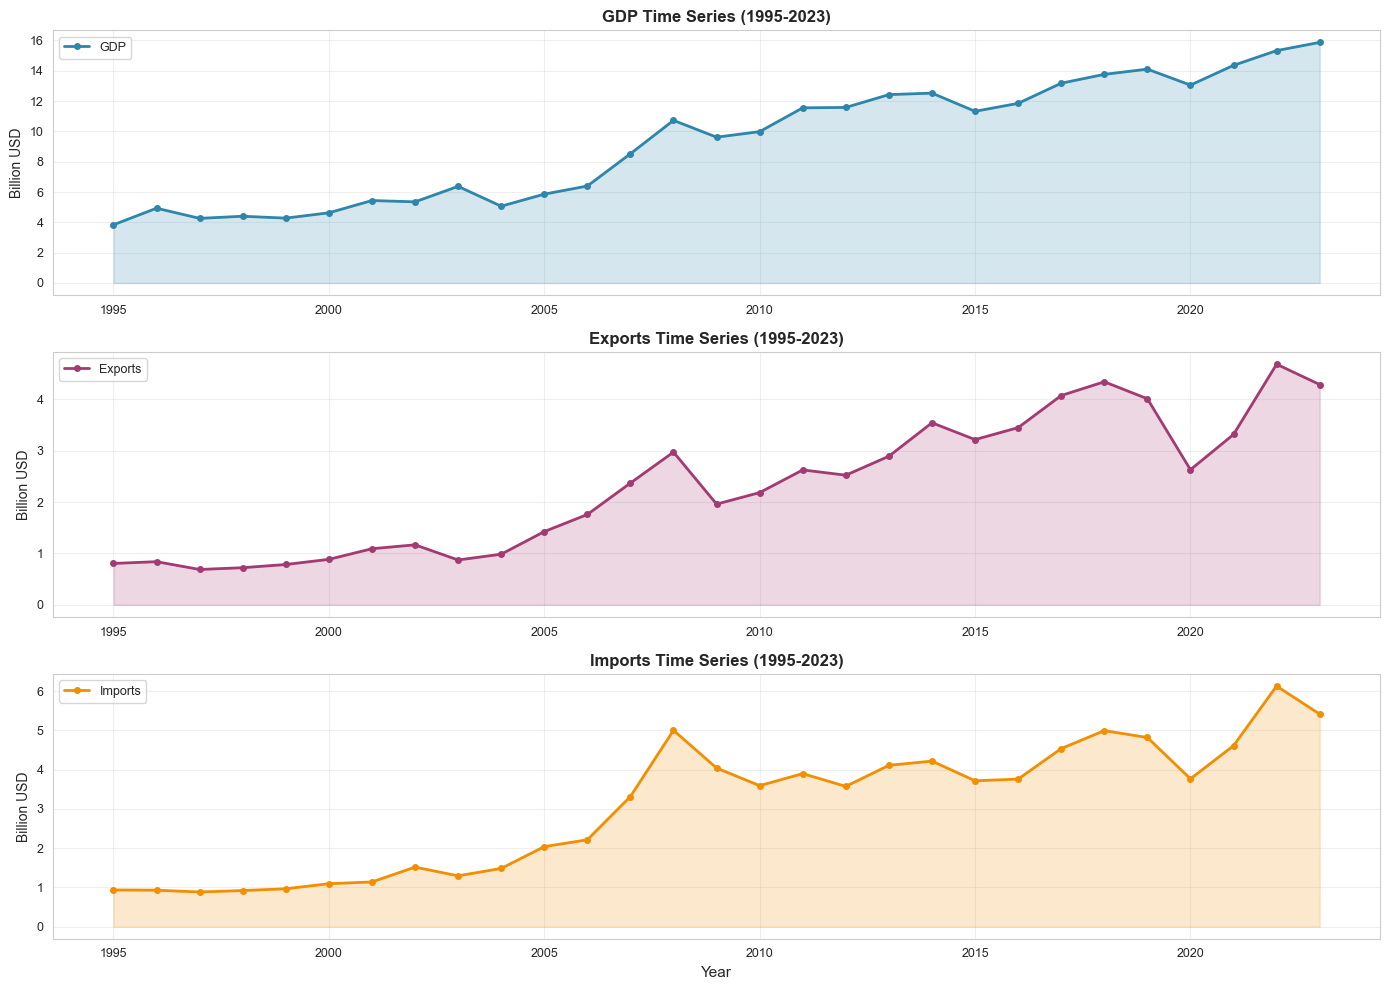

In [7]:
# 2.4 Visualization: Time Series Plots
print("\n2.4 Creating visualizations...")

# Define color palette for consistent styling
colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange

# Plot 1: Individual time series for each variable
fig, axes = plt.subplots(3, 1, figsize=(14, 10))  # 3 rows, 1 column
for idx, (col, color) in enumerate(zip(df_sel.columns, colors)):
    # Plot the time series
    axes[idx].plot(df_sel.index, df_sel[col]/1e9, marker='o', linewidth=2, 
                   color=color, markersize=4, label=col)
    # Add shaded area under the curve
    axes[idx].fill_between(df_sel.index, 0, df_sel[col]/1e9, alpha=0.2, color=color)
    # Set labels and title
    axes[idx].set_title(f'{col} Time Series (1995-2023)', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('Billion USD', fontsize=10)
    axes[idx].grid(True, alpha=0.3)  # Add grid for readability
    axes[idx].legend()

axes[2].set_xlabel('Year', fontsize=11)
plt.tight_layout()  # Adjust spacing between subplots
plt.savefig('fig_01_timeseries_individual.png', dpi=300, bbox_inches='tight')
plt.show()  # Display in notebook/IDE
plt.close()

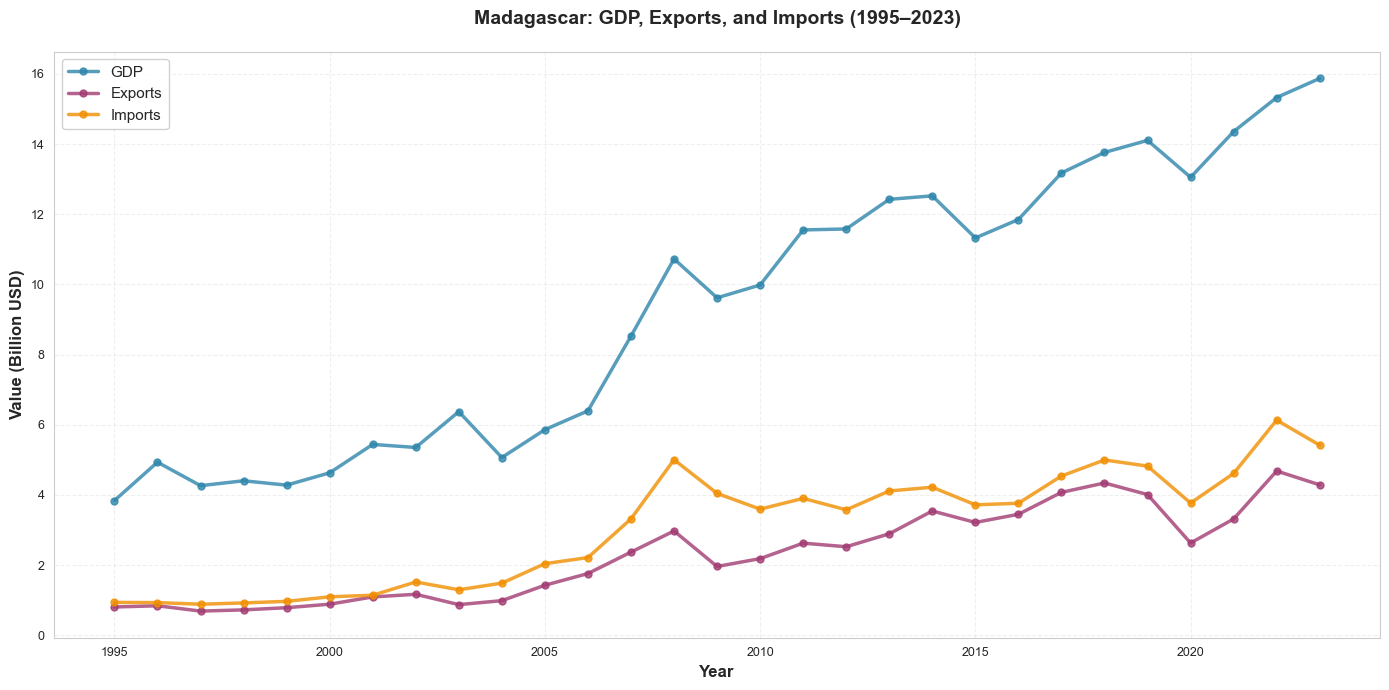

In [8]:
# Plot 2: Combined time series plot
plt.figure(figsize=(14, 7))
for col, color in zip(df_sel.columns, colors):
    plt.plot(df_sel.index, df_sel[col]/1e9, label=col, marker='o', 
             linewidth=2.5, color=color, markersize=5, alpha=0.8)

plt.title('Madagascar: GDP, Exports, and Imports (1995–2023)', 
          fontweight='bold', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Value (Billion USD)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('fig_01_timeseries_combined.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

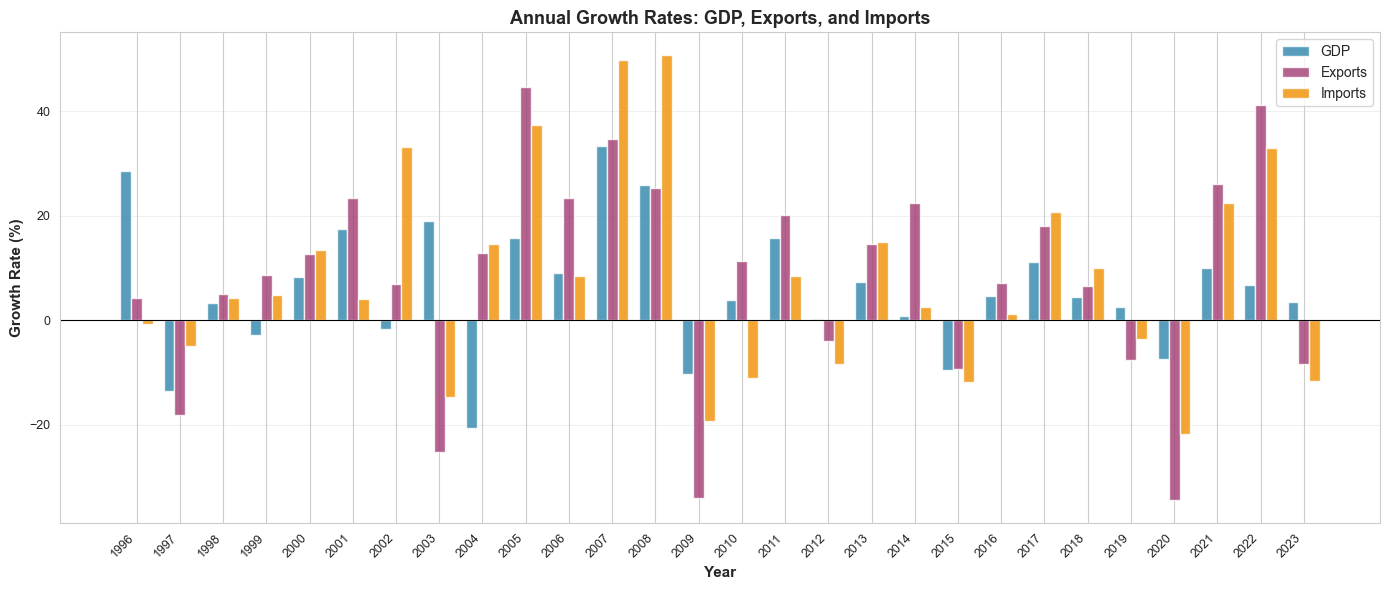

In [9]:
# Plot 3: Growth rates (year-over-year percentage change)
# Growth rates are important for understanding dynamics in time series
df_growth = df_sel.pct_change() * 100  # Calculate percentage change
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(df_growth.index[1:]))  # X-axis positions
width = 0.25  # Width of bars

# Create grouped bar chart
for idx, (col, color) in enumerate(zip(df_growth.columns, colors)):
    ax.bar(x + idx*width, df_growth[col].iloc[1:], width, 
           label=col, color=color, alpha=0.8)

ax.set_xlabel('Year', fontweight='bold', fontsize=11)
ax.set_ylabel('Growth Rate (%)', fontweight='bold', fontsize=11)
ax.set_title('Annual Growth Rates: GDP, Exports, and Imports', 
             fontweight='bold', fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels(df_growth.index[1:], rotation=45, ha='right')
ax.legend(fontsize=10)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)  # Reference line at 0
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig_01_growth_rates.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

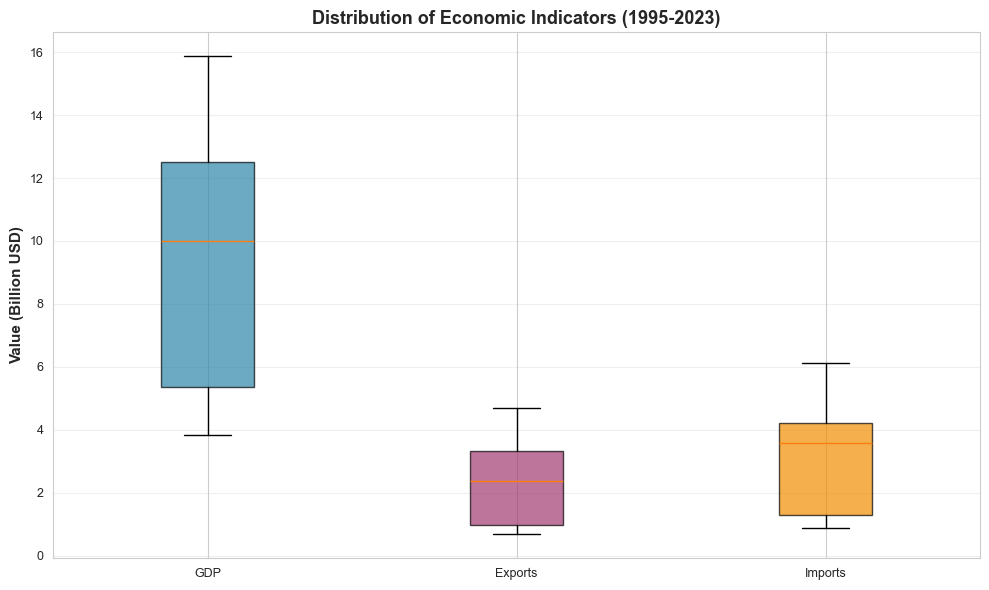

In [10]:
# Plot 4: Box plots to show distribution and outliers
fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot([df_sel[col]/1e9 for col in df_sel.columns], 
                 labels=df_sel.columns, patch_artist=True)
# Color each box
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Value (Billion USD)', fontweight='bold', fontsize=11)
ax.set_title('Distribution of Economic Indicators (1995-2023)', 
             fontweight='bold', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig_01_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

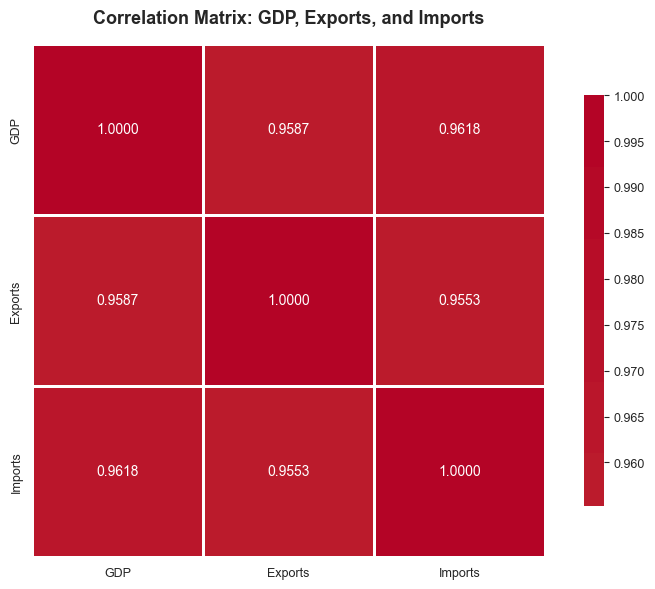

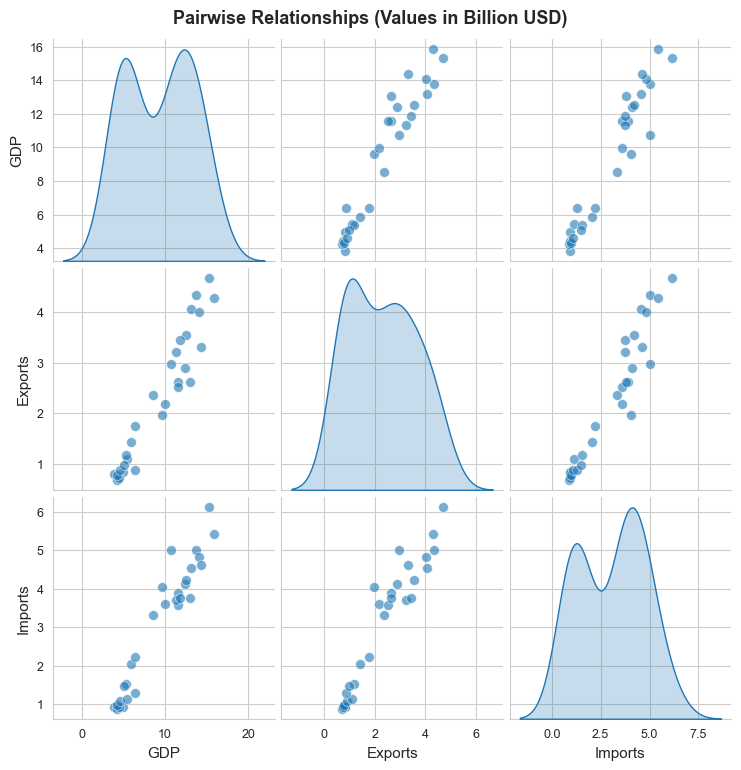

✓ Exploratory Data Analysis complete. All visualizations saved.


In [11]:
# Plot 5: Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: GDP, Exports, and Imports', 
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('fig_01_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Plot 6: Pairwise scatter plots
pair_plot = sns.pairplot(df_sel/1e9, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 50})
pair_plot.fig.suptitle('Pairwise Relationships (Values in Billion USD)', 
                       y=1.02, fontweight='bold', fontsize=13)
plt.savefig('fig_01_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("✓ Exploratory Data Analysis complete. All visualizations saved.")


# -----------
# # SECTION 3: LOG TRANSFORMATION AND STATIONARITY TESTS
# -----------

# -----------
# # SECTION 3: LOG TRANSFORMATION AND STATIONARITY TESTS
# ## 3.1 Log Transformation
# -----------


PART 3: LOG TRANSFORMATION AND STATIONARITY ANALYSIS
--------------------------------------------------------------------------------

Objective: Test for stationarity, a key assumption in time series analysis
Concepts: Unit root tests (ADF, KPSS), differencing, integration order
Reference: Lecture notes on time series properties and stationarity

3.1 Applying Log Transformation
    Reason: Logarithms stabilize variance and linearize exponential growth
    ✓ Log transformation successful

    Original vs Log-transformed data (first 5 rows):
        GDP  log(GDP)  Exports  log(Exports)
Year                                        
1995  3.838    22.068    0.805        20.507
1996  4.932    22.319    0.840        20.548
1997  4.263    22.173    0.688        20.350
1998  4.402    22.205    0.722        20.398
1999  4.278    22.177    0.785        20.481


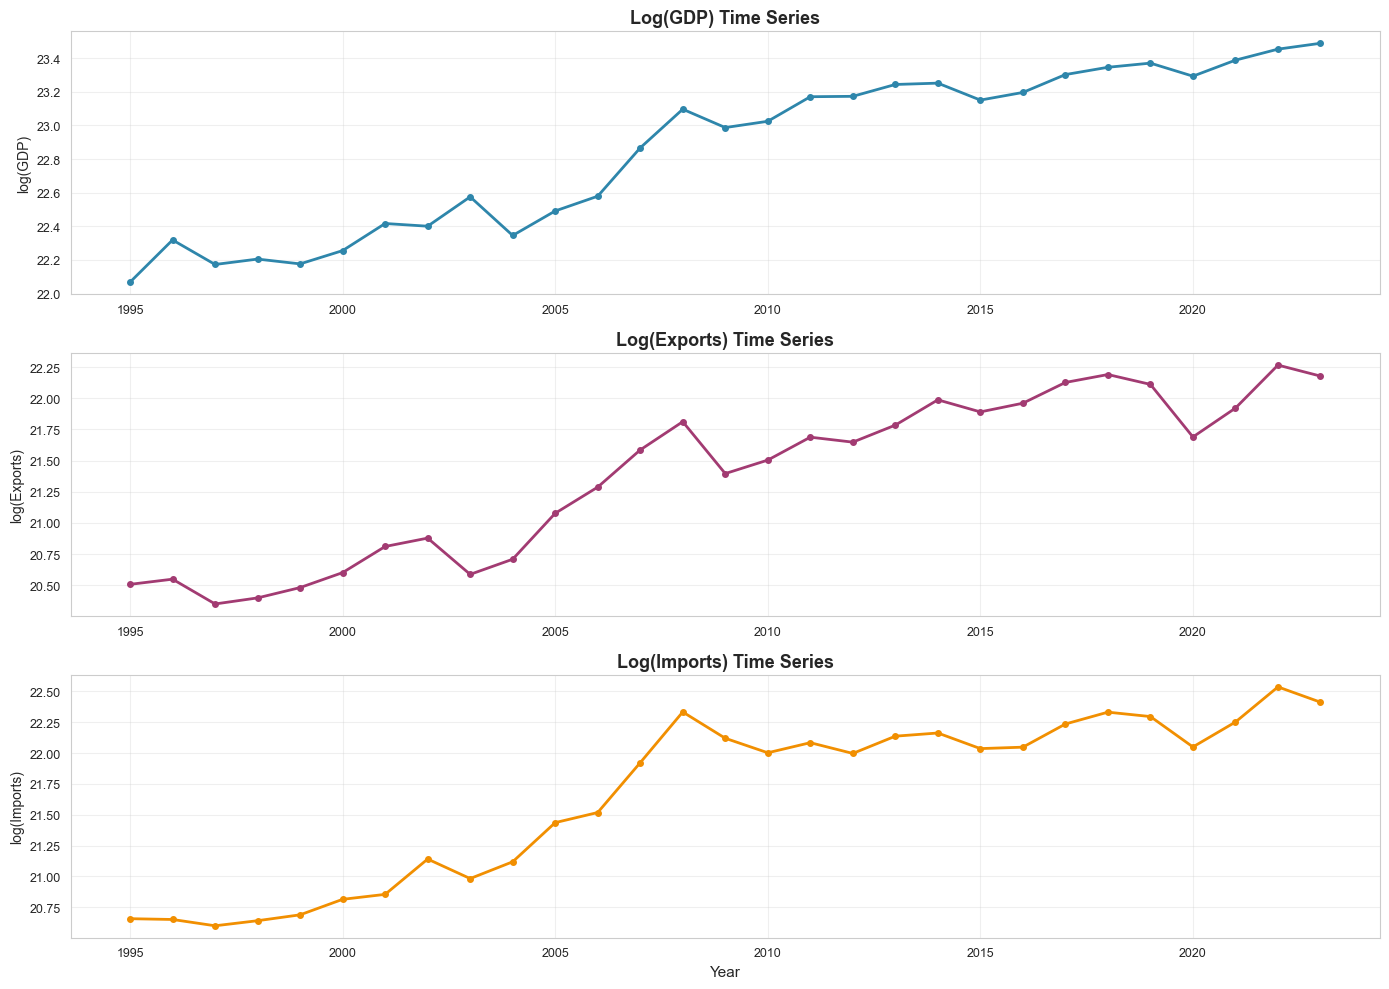

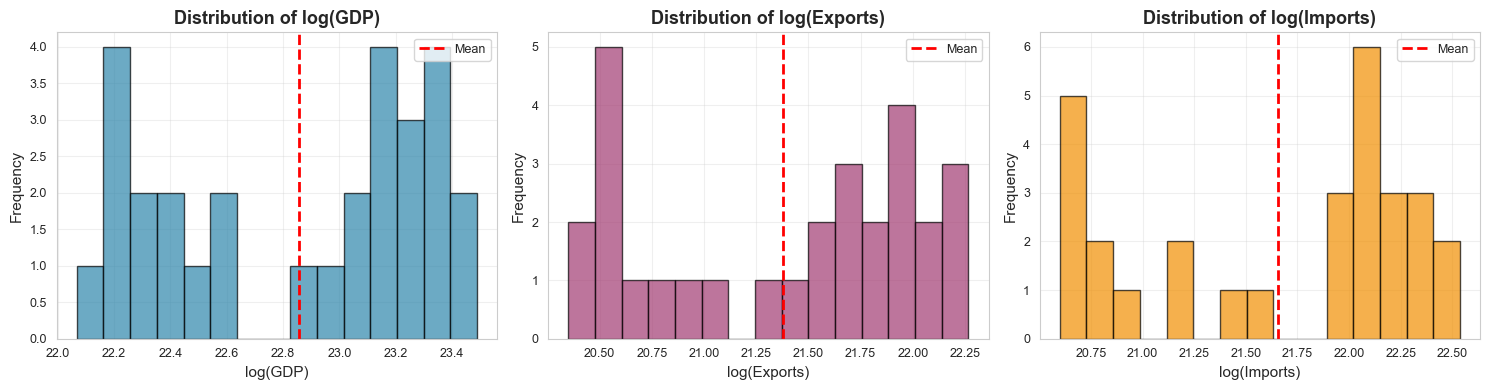

In [12]:
print("\n" + "=" * 80)
print("PART 3: LOG TRANSFORMATION AND STATIONARITY ANALYSIS")
print("-" * 80)
print("\nObjective: Test for stationarity, a key assumption in time series analysis")
print("Concepts: Unit root tests (ADF, KPSS), differencing, integration order")
print("Reference: Lecture notes on time series properties and stationarity")

# 3.1 Log Transformation
# Taking logs helps stabilize variance and makes relationships more linear
# Also converts growth rates to differences
print("\n3.1 Applying Log Transformation")
print("    Reason: Logarithms stabilize variance and linearize exponential growth")

# Check for non-positive values (logs undefined for zero or negative numbers)
if (df_sel <= 0).any().any():
    print("    WARNING: Zero or negative values detected! Cannot apply log transformation.")
    print("    Check your data for errors.")
else:
    df_log = np.log(df_sel)  # Apply natural logarithm
    print("    ✓ Log transformation successful")

    # Display comparison
    print("\n    Original vs Log-transformed data (first 5 rows):")
    comparison = pd.DataFrame({
        'GDP': df_sel['GDP'].head() / 1e9,
        'log(GDP)': df_log['GDP'].head(),
        'Exports': df_sel['Exports'].head() / 1e9,
        'log(Exports)': df_log['Exports'].head()
    })
    print(comparison.round(3))

    # Plot log-transformed series
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    for idx, (col, color) in enumerate(zip(df_log.columns, colors)):
        axes[idx].plot(df_log.index, df_log[col], marker='o', 
                      linewidth=2, color=color, markersize=4)
        axes[idx].set_title(f'Log({col}) Time Series', fontweight='bold')
        axes[idx].set_ylabel(f'log({col})', fontsize=10)
        axes[idx].grid(True, alpha=0.3)
    axes[2].set_xlabel('Year', fontsize=11)
    plt.tight_layout()
    plt.savefig('fig_02_log_series.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # Plot histograms of log-transformed data
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, (col, color) in enumerate(zip(df_log.columns, colors)):
        axes[i].hist(df_log[col], bins=15, alpha=0.7, color=color, edgecolor='black')
        axes[i].axvline(df_log[col].mean(), color='red', linestyle='--', 
                       linewidth=2, label='Mean')
        axes[i].set_title(f'Distribution of log({col})', fontweight='bold')
        axes[i].set_xlabel(f'log({col})')
        axes[i].set_ylabel('Frequency')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig_02_log_histograms.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


# -----------
# # SECTION 3: LOG TRANSFORMATION AND STATIONARITY TESTS
# ## 3.2 Stationarity Tests on Log Levels
# -----------

In [13]:
# 3.2 Stationarity Tests on Log Levels
print("\n3.2 Stationarity Tests on Log Levels")
print("    Testing H0: Series has a unit root (non-stationary)")
print("-" * 80)

# We use two tests:
# 1. ADF (Augmented Dickey-Fuller): H0 = unit root (non-stationary)
# 2. KPSS (Kwiatkowski-Phillips-Schmidt-Shin): H0 = stationary

adf_results = {}   # Store ADF test results
kpss_results = {}  # Store KPSS test results
stationarity_log = []  # Store combined results

for col in df_log.columns:
    series = df_log[col].dropna()  # Remove any NaN values

    # Perform ADF test with constant and trend
    # Returns: test statistic, p-value, lags used, number of obs, critical values, IC used
    adf_stat, adf_p, adf_usedlag, adf_nobs, adf_crit, _ = adfuller(series, regression='ct')

    # Perform KPSS test with constant and trend
    # Need to determine number of lags for KPSS
    n = len(series)
    nlags_kpss = int(4 * (n/100)**(1/4))  # Schwert's formula for lag selection
    try:
        kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series, regression='ct', nlags=nlags_kpss)
    except:
        # Fallback to legacy method if calculation fails
        kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series, regression='ct', nlags='legacy')

    # Store results
    adf_results[col] = (adf_stat, adf_p)
    kpss_results[col] = (kpss_stat, kpss_p)

    # Interpret results
    # ADF: reject H0 if p < 0.05 → series is stationary
    # KPSS: reject H0 if p < 0.05 → series is non-stationary
    adf_decision = "Stationary" if adf_p < 0.05 else "Non-stationary"
    kpss_decision = "Stationary" if kpss_p > 0.05 else "Non-stationary"

    stationarity_log.append({
        'Variable': col,
        'ADF Statistic': adf_stat,
        'ADF p-value': adf_p,
        'ADF Decision': adf_decision,
        'KPSS Statistic': kpss_stat,
        'KPSS p-value': kpss_p,
        'KPSS Decision': kpss_decision
    })

    # Print detailed results
    print(f"\n{col}:")
    print(f"  ADF Test:")
    print(f"    • Test statistic: {adf_stat:.4f}")
    print(f"    • p-value: {adf_p:.4f}")
    print(f"    • Critical values: 1%={adf_crit['1%']:.3f}, 5%={adf_crit['5%']:.3f}, 10%={adf_crit['10%']:.3f}")
    print(f"    • Decision: {adf_decision}")
    if adf_p < 0.05:
        print(f"    • Interpretation: Reject H0, series is stationary at 5% level")
    else:
        print(f"    • Interpretation: Cannot reject H0, series appears non-stationary")

    print(f"  KPSS Test:")
    print(f"    • Test statistic: {kpss_stat:.4f}")
    print(f"    • p-value: {kpss_p:.4f}")
    print(f"    • Critical values: 10%={kpss_crit['10%']:.3f}, 5%={kpss_crit['5%']:.3f}, 2.5%={kpss_crit['2.5%']:.3f}")
    print(f"    • Decision: {kpss_decision}")
    if kpss_p > 0.05:
        print(f"    • Interpretation: Cannot reject H0, series is stationary")
    else:
        print(f"    • Interpretation: Reject H0, series is non-stationary")

    # Overall conclusion using both tests
    print(f"  Combined Interpretation:")
    if adf_decision == "Non-stationary" and kpss_decision == "Non-stationary":
        print(f"    → Both tests indicate NON-STATIONARITY (unit root present)")
        print(f"    → Series is I(1), need to take first differences")
    elif adf_decision == "Stationary" and kpss_decision == "Stationary":
        print(f"    → Both tests indicate STATIONARITY")
        print(f"    → Series is I(0), suitable for regression in levels")
    else:
        print(f"    → Tests give conflicting results (borderline case)")

# Save results to CSV
stationarity_log_df = pd.DataFrame(stationarity_log)
stationarity_log_df.to_csv('03_stationarity_tests_log_levels.csv', index=False)
print("\n✓ Stationarity tests on log levels saved to '03_stationarity_tests_log_levels.csv'")


# -----------
# # SECTION 3: LOG TRANSFORMATION AND STATIONARITY TESTS
# ## 3.3 First Differences (Growth Rates)
# -----------


3.2 Stationarity Tests on Log Levels
    Testing H0: Series has a unit root (non-stationary)
--------------------------------------------------------------------------------

GDP:
  ADF Test:
    • Test statistic: -2.4197
    • p-value: 0.3692
    • Critical values: 1%=-4.324, 5%=-3.581, 10%=-3.225
    • Decision: Non-stationary
    • Interpretation: Cannot reject H0, series appears non-stationary
  KPSS Test:
    • Test statistic: 0.1522
    • p-value: 0.0448
    • Critical values: 10%=0.119, 5%=0.146, 2.5%=0.176
    • Decision: Non-stationary
    • Interpretation: Reject H0, series is non-stationary
  Combined Interpretation:
    → Both tests indicate NON-STATIONARITY (unit root present)
    → Series is I(1), need to take first differences

Exports:
  ADF Test:
    • Test statistic: -2.5793
    • p-value: 0.2895
    • Critical values: 1%=-4.324, 5%=-3.581, 10%=-3.225
    • Decision: Non-stationary
    • Interpretation: Cannot reject H0, series appears non-stationary
  KPSS Test:
   


3.3 Testing Stationarity of First Differences
    First difference of log = growth rate
    Δlog(Y_t) = log(Y_t) - log(Y_{t-1}) ≈ (Y_t - Y_{t-1})/Y_{t-1}
--------------------------------------------------------------------------------

    Observations after differencing: 28 (lost 1 observation)

Δlog(GDP) [Growth Rate]:
  ADF: statistic=-6.6697, p-value=0.0000 → Stationary
  KPSS: statistic=0.0897, p-value=0.1000 → Stationary
  ✓ First difference is STATIONARY → Original series is I(1)

Δlog(Exports) [Growth Rate]:
  ADF: statistic=-5.5625, p-value=0.0000 → Stationary
  KPSS: statistic=0.0722, p-value=0.1000 → Stationary
  ✓ First difference is STATIONARY → Original series is I(1)

Δlog(Imports) [Growth Rate]:
  ADF: statistic=-1.8617, p-value=0.3503 → Non-stationary
  KPSS: statistic=0.1266, p-value=0.1000 → Stationary


/var/folders/l5/4n7gm0vs3gb3bddszy60wfmh0000gn/T/ipykernel_38242/3460526649.py:27: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series, regression='c', nlags=nlags_kpss)
/var/folders/l5/4n7gm0vs3gb3bddszy60wfmh0000gn/T/ipykernel_38242/3460526649.py:27: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series, regression='c', nlags=nlags_kpss)
/var/folders/l5/4n7gm0vs3gb3bddszy60wfmh0000gn/T/ipykernel_38242/3460526649.py:27: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series, regression=

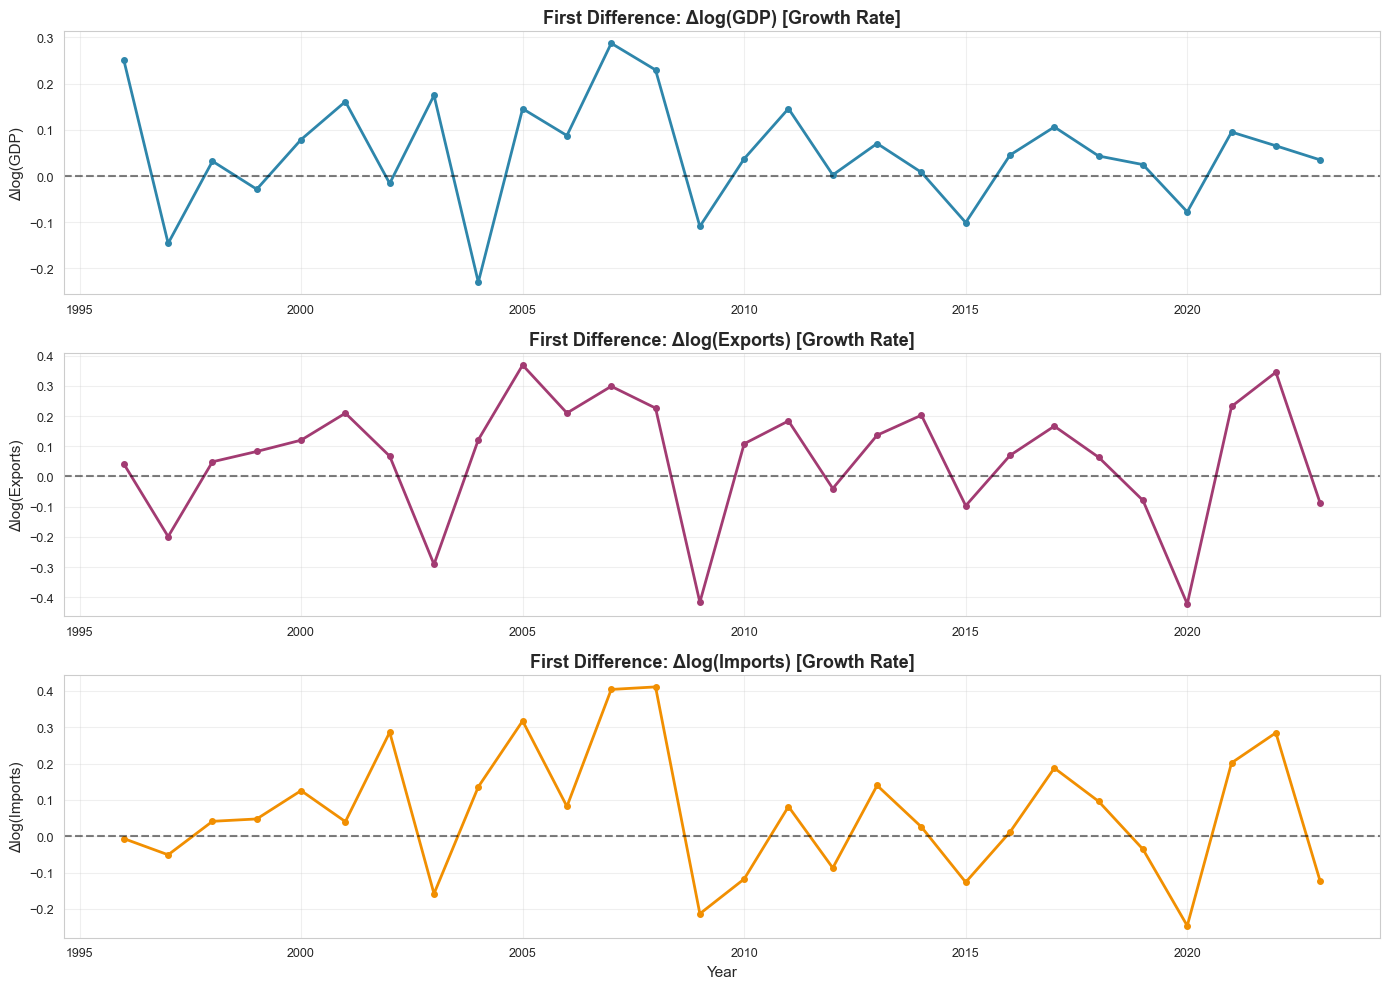


✓ Stationarity analysis complete.
  Files saved: '03_stationarity_tests_differences.csv', 'fig_03_differenced_series.png'


In [14]:
# 3.3 First Differences (Growth Rates)
print("\n3.3 Testing Stationarity of First Differences")
print("    First difference of log = growth rate")
print("    Δlog(Y_t) = log(Y_t) - log(Y_{t-1}) ≈ (Y_t - Y_{t-1})/Y_{t-1}")
print("-" * 80)

# Calculate first differences
df_dlog = df_log.diff().dropna()  # diff() computes X_t - X_{t-1}, dropna() removes first row (NaN)

print(f"\n    Observations after differencing: {len(df_dlog)} (lost 1 observation)")

# Perform stationarity tests on differenced series
adf_diff = {}
kpss_diff = {}
stationarity_diff = []

for col in df_dlog.columns:
    series = df_dlog[col]

    # ADF test (with constant only, no trend for differences)
    adf_stat, adf_p, adf_usedlag, adf_nobs, adf_crit, _ = adfuller(series, regression='c')

    # KPSS test (with constant only)
    n = len(series)
    nlags_kpss = int(4 * (n/100)**(1/4))
    try:
        kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series, regression='c', nlags=nlags_kpss)
    except:
        kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(series, regression='c', nlags='legacy')

    adf_diff[col] = (adf_stat, adf_p)
    kpss_diff[col] = (kpss_stat, kpss_p)

    adf_decision = "Stationary" if adf_p < 0.05 else "Non-stationary"
    kpss_decision = "Stationary" if kpss_p > 0.05 else "Non-stationary"

    stationarity_diff.append({
        'Variable': f'Δlog({col})',
        'ADF Statistic': adf_stat,
        'ADF p-value': adf_p,
        'ADF Decision': adf_decision,
        'KPSS Statistic': kpss_stat,
        'KPSS p-value': kpss_p,
        'KPSS Decision': kpss_decision
    })

    print(f"\nΔlog({col}) [Growth Rate]:")
    print(f"  ADF: statistic={adf_stat:.4f}, p-value={adf_p:.4f} → {adf_decision}")
    print(f"  KPSS: statistic={kpss_stat:.4f}, p-value={kpss_p:.4f} → {kpss_decision}")
    if adf_decision == "Stationary" and kpss_decision == "Stationary":
        print(f"  ✓ First difference is STATIONARY → Original series is I(1)")

# Save results
stationarity_diff_df = pd.DataFrame(stationarity_diff)
stationarity_diff_df.to_csv('03_stationarity_tests_differences.csv', index=False)

# Plot differenced series
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for idx, (col, color) in enumerate(zip(df_dlog.columns, colors)):
    axes[idx].plot(df_dlog.index, df_dlog[col], marker='o', 
                  linewidth=2, color=color, markersize=4)
    axes[idx].axhline(y=0, color='black', linestyle='--', alpha=0.5)  # Reference line at zero
    axes[idx].set_title(f'First Difference: Δlog({col}) [Growth Rate]', fontweight='bold')
    axes[idx].set_ylabel(f'Δlog({col})')
    axes[idx].grid(True, alpha=0.3)
axes[2].set_xlabel('Year', fontsize=11)
plt.tight_layout()
plt.savefig('fig_03_differenced_series.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\n✓ Stationarity analysis complete.")
print("  Files saved: '03_stationarity_tests_differences.csv', 'fig_03_differenced_series.png'")



# -----------
# # SECTION 4: COINTEGRATION ANALYSIS (JOHANSEN TEST)
# -----------

In [15]:
print("\n" + "=" * 80)
print("PART 4: COINTEGRATION ANALYSIS")
print("-" * 80)
print("\nObjective: Test if non-stationary variables share a long-run equilibrium")
print("Concept: Cointegration (Engle-Granger, Johansen)")
print("Interpretation: If cointegrated, there's a stable long-run relationship")

# Johansen test requires sufficient observations
if len(df_log) >= 10:
    print(f"\n4.1 Performing Johansen Cointegration Test")
    print(f"    Sample size: {len(df_log)} observations")

    # Run Johansen test
    # det_order=0: no deterministic trend in cointegration relation
    # k_ar_diff=1: use 1 lag in differences
    jres = coint_johansen(df_log.values, det_order=0, k_ar_diff=1)

    print("\n4.2 Johansen Cointegration Test Results:")
    print("-" * 80)

    # Extract test statistics and critical values
    trace_stats = jres.lr1      # Trace statistic
    trace_cv = jres.cvt         # Critical values for trace statistic
    maxeig_stats = jres.lr2     # Maximum eigenvalue statistic
    maxeig_cv = jres.cvm        # Critical values for max eigenvalue statistic

    # Build results table
    johansen_results = []
    for i in range(len(trace_stats)):
        johansen_results.append({
            'Hypothesis': f'r ≤ {i}',
            'Trace Stat': trace_stats[i],
            'Trace CV (90%)': trace_cv[i, 0],
            'Trace CV (95%)': trace_cv[i, 1],
            'Trace CV (99%)': trace_cv[i, 2],
            'Trace Reject 95%': 'Yes' if trace_stats[i] > trace_cv[i, 1] else 'No',
            'Max-Eigen Stat': maxeig_stats[i],
            'Max-Eigen CV (95%)': maxeig_cv[i, 1],
            'Max-Eigen Reject 95%': 'Yes' if maxeig_stats[i] > maxeig_cv[i, 1] else 'No'
        })

    # Display results
    johansen_df = pd.DataFrame(johansen_results)
    print(johansen_df.to_string(index=False))
    johansen_df.to_csv('04_johansen_cointegration.csv', index=False)

    # Determine cointegration rank
    # Count how many hypotheses we can reject
    rank = 0
    for i, stat in enumerate(trace_stats):
        if stat > trace_cv[i, 1]:  # Compare with 95% critical value
            rank = i + 1

    print(f"\n{'=' * 80}")
    print(f"COINTEGRATION RANK (at 5% significance): {rank}")
    print(f"{'=' * 80}")

    # Interpret results
    if rank > 0:
        print(f"\n4.3 Interpretation:")
        print(f"    ✓ Found {rank} cointegrating relationship(s)")
        print(f"    → Variables share {rank} long-run equilibrium relationship(s)")
        print(f"    → Despite being non-stationary individually, a linear combination is stationary")
        print(f"    → Can use VECM (Vector Error Correction Model) for estimation")
        print(f"    → Economic interpretation: GDP, Exports, and Imports move together in the long run")
    else:
        print(f"\n4.3 Interpretation:")
        print(f"    ✗ No cointegration detected")
        print(f"    → Variables do not share a long-run equilibrium")
        print(f"    → Should work with differenced data (growth rates)")
        print(f"    → Use VAR model on differences, not VECM")
else:
    print(f"\nWARNING: Insufficient observations ({len(df_log)}) for Johansen test")
    print("         Need at least 10 observations. Skipping cointegration analysis.")
    rank = 0

print("\n✓ Cointegration analysis complete. Results saved to '04_johansen_cointegration.csv'")


# -----------
# # SECTION 5: OLS REGRESSION ANALYSIS
# ## 5.1 Model Specification
# -----------


PART 4: COINTEGRATION ANALYSIS
--------------------------------------------------------------------------------

Objective: Test if non-stationary variables share a long-run equilibrium
Concept: Cointegration (Engle-Granger, Johansen)
Interpretation: If cointegrated, there's a stable long-run relationship

4.1 Performing Johansen Cointegration Test
    Sample size: 29 observations

4.2 Johansen Cointegration Test Results:
--------------------------------------------------------------------------------
Hypothesis  Trace Stat  Trace CV (90%)  Trace CV (95%)  Trace CV (99%) Trace Reject 95%  Max-Eigen Stat  Max-Eigen CV (95%) Max-Eigen Reject 95%
     r ≤ 0   23.152115         27.0669         29.7961         35.4628               No       13.869319             21.1314                   No
     r ≤ 1    9.282796         13.4294         15.4943         19.9349               No        7.598091             14.2639                   No
     r ≤ 2    1.684705          2.7055          3.8415   

In [16]:
print("\n" + "=" * 80)
print("PART 5: OLS REGRESSION ANALYSIS")
print("-" * 80)
print("\nObjective: Estimate the relationship between GDP growth and trade")
print("Model: Δlog(GDP) = β₀ + β₁·Δlog(Exports) + β₂·Δlog(Imports) + ε")
print("Interpretation: β coefficients measure elasticities")

# 5.1 Model Specification
print("\n5.1 Model Specification")
print("    Dependent variable (Y): Δlog(GDP) [GDP growth rate]")
print("    Independent variables (X):")
print("        • Δlog(Exports) [Export growth rate]")
print("        • Δlog(Imports) [Import growth rate]")
print("    Estimation method: Ordinary Least Squares (OLS)")

# Prepare data for regression
Y = df_dlog['GDP']                           # Dependent variable
X = df_dlog[['Exports', 'Imports']]         # Independent variables
X = sm.add_constant(X)                       # Add constant term (intercept)

print(f"\n    Sample size: {len(Y)} observations")
print(f"    Variables in X: {list(X.columns)}")


# -----------
# # SECTION 5: OLS REGRESSION ANALYSIS
# ## 5.2 Estimate OLS model
# -----------


PART 5: OLS REGRESSION ANALYSIS
--------------------------------------------------------------------------------

Objective: Estimate the relationship between GDP growth and trade
Model: Δlog(GDP) = β₀ + β₁·Δlog(Exports) + β₂·Δlog(Imports) + ε
Interpretation: β coefficients measure elasticities

5.1 Model Specification
    Dependent variable (Y): Δlog(GDP) [GDP growth rate]
    Independent variables (X):
        • Δlog(Exports) [Export growth rate]
        • Δlog(Imports) [Import growth rate]
    Estimation method: Ordinary Least Squares (OLS)

    Sample size: 28 observations
    Variables in X: ['const', 'Exports', 'Imports']


In [17]:
# 5.2 Estimate OLS model
print("\n5.2 Estimating OLS Model...")
model_ols = sm.OLS(Y, X).fit()  # Fit OLS regression

# Display full regression results
print("\n" + "=" * 80)
print("OLS REGRESSION RESULTS")
print("=" * 80)
print(model_ols.summary())


# -----------
# # SECTION 5: OLS REGRESSION ANALYSIS
# ## 5.3 Interpret Coefficients
# -----------


5.2 Estimating OLS Model...

OLS REGRESSION RESULTS
                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     4.238
Date:                Fri, 24 Apr 2026   Prob (F-statistic):             0.0260
Time:                        17:41:22   Log-Likelihood:                 24.552
No. Observations:                  28   AIC:                            -43.10
Df Residuals:                      25   BIC:                            -39.11
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [18]:
# 5.3 Interpret Coefficients
print("\n5.3 Detailed Coefficient Interpretation:")
print("-" * 80)

for var in X.columns:
    coef = model_ols.params[var]
    se = model_ols.bse[var]
    t_stat = model_ols.tvalues[var]
    p_val = model_ols.pvalues[var]
    ci_lower, ci_upper = model_ols.conf_int().loc[var]

    print(f"\n{var}:")
    print(f"  • Coefficient: {coef:.6f}")
    print(f"  • Standard Error: {se:.6f}")
    print(f"  • t-statistic: {t_stat:.4f}")
    print(f"  • p-value: {p_val:.4f}")
    print(f"  • 95% Confidence Interval: [{ci_lower:.6f}, {ci_upper:.6f}]")

    if var != 'const':
        print(f"  • Economic Interpretation:")
        if p_val < 0.05:
            print(f"    → STATISTICALLY SIGNIFICANT at 5% level")
            print(f"    → A 1% increase in {var.lower()} growth is associated with")
            print(f"      a {coef:.4f}% change in GDP growth, holding other factors constant")
            if coef > 0:
                print(f"    → POSITIVE relationship: higher {var.lower()} growth → higher GDP growth")
            else:
                print(f"    → NEGATIVE relationship: higher {var.lower()} growth → lower GDP growth")
        else:
            print(f"    → NOT statistically significant (p > 0.05)")
            print(f"    → Cannot conclude {var.lower()} has a significant effect on GDP growth")


# -----------
# # SECTION 5: OLS REGRESSION ANALYSIS
# ## 5.4 Model Goodness of Fit
# -----------


5.3 Detailed Coefficient Interpretation:
--------------------------------------------------------------------------------

const:
  • Coefficient: 0.030912
  • Standard Error: 0.021425
  • t-statistic: 1.4428
  • p-value: 0.1615
  • 95% Confidence Interval: [-0.013214, 0.075038]

Exports:
  • Coefficient: 0.188253
  • Standard Error: 0.176807
  • t-statistic: 1.0647
  • p-value: 0.2972
  • 95% Confidence Interval: [-0.175888, 0.552393]
  • Economic Interpretation:
    → NOT statistically significant (p > 0.05)
    → Cannot conclude exports has a significant effect on GDP growth

Imports:
  • Coefficient: 0.136286
  • Standard Error: 0.205467
  • t-statistic: 0.6633
  • p-value: 0.5132
  • 95% Confidence Interval: [-0.286881, 0.559454]
  • Economic Interpretation:
    → NOT statistically significant (p > 0.05)
    → Cannot conclude imports has a significant effect on GDP growth


In [19]:
# 5.4 Model Goodness of Fit
print("\n5.4 Model Goodness of Fit:")
print("-" * 80)
print(f"  • R-squared: {model_ols.rsquared:.4f}")
print(f"    → {model_ols.rsquared*100:.2f}% of GDP growth variation is explained by the model")
print(f"  • Adjusted R-squared: {model_ols.rsquared_adj:.4f}")
print(f"    → Accounts for number of predictors (penalizes overfitting)")
print(f"  • F-statistic: {model_ols.fvalue:.4f}")
print(f"  • F-statistic p-value: {model_ols.f_pvalue:.6f}")
if model_ols.f_pvalue < 0.05:
    print(f"    → Model is STATISTICALLY SIGNIFICANT overall")
    print(f"    → At least one predictor has a non-zero coefficient")
else:
    print(f"    → Model is NOT significant overall")

# Save detailed coefficient table
coef_df = pd.DataFrame({
    'Coefficient': model_ols.params,
    'Std Error': model_ols.bse,
    't-statistic': model_ols.tvalues,
    'p-value': model_ols.pvalues,
    'CI Lower (95%)': model_ols.conf_int()[0],
    'CI Upper (95%)': model_ols.conf_int()[1]
})
coef_df.to_csv('05_ols_coefficients_detailed.csv')

# Save model statistics
model_stats = {
    'R-squared': model_ols.rsquared,
    'Adjusted R-squared': model_ols.rsquared_adj,
    'F-statistic': model_ols.fvalue,
    'F-statistic p-value': model_ols.f_pvalue,
    'AIC': model_ols.aic,
    'BIC': model_ols.bic,
    'Log-Likelihood': model_ols.llf,
    'Observations': model_ols.nobs,
    'Degrees of Freedom (Residual)': model_ols.df_resid
}
model_stats_df = pd.DataFrame.from_dict(model_stats, orient='index', columns=['Value'])
model_stats_df.to_csv('05_ols_model_statistics.csv')


# -----------
# # SECTION 5: OLS REGRESSION ANALYSIS
# ## 5.5 Visualize Coefficients
# -----------


5.4 Model Goodness of Fit:
--------------------------------------------------------------------------------
  • R-squared: 0.2532
    → 25.32% of GDP growth variation is explained by the model
  • Adjusted R-squared: 0.1935
    → Accounts for number of predictors (penalizes overfitting)
  • F-statistic: 4.2382
  • F-statistic p-value: 0.026003
    → Model is STATISTICALLY SIGNIFICANT overall
    → At least one predictor has a non-zero coefficient



5.5 Creating coefficient plot...


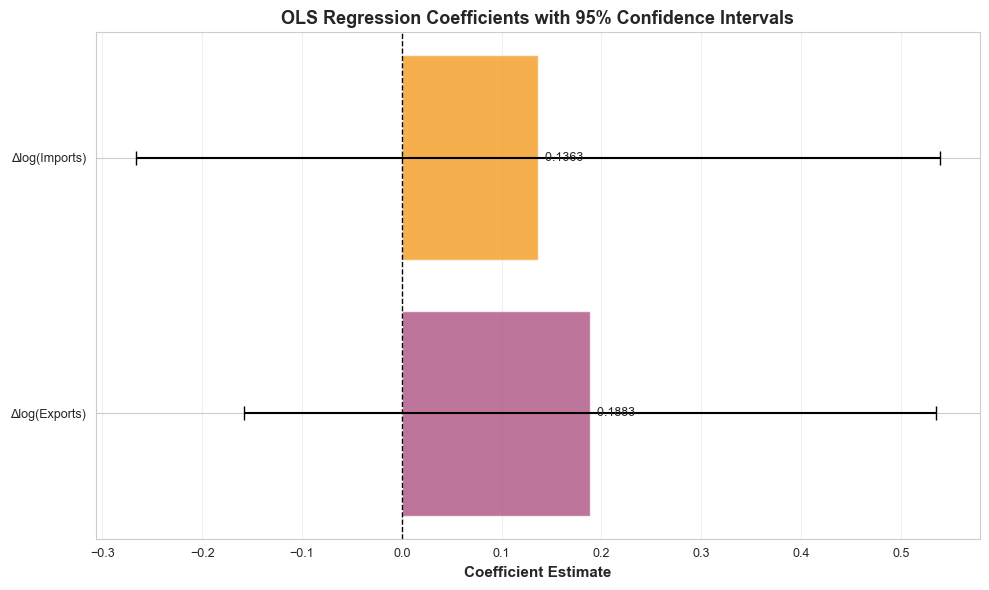


✓ OLS regression complete. Results saved.


In [20]:
# 5.5 Visualize Coefficients
print("\n5.5 Creating coefficient plot...")
fig, ax = plt.subplots(figsize=(10, 6))
coefs = model_ols.params[1:]  # Exclude constant
errors = model_ols.bse[1:] * 1.96  # 95% CI = ±1.96 * SE
y_pos = np.arange(len(coefs))

ax.barh(y_pos, coefs, xerr=errors, align='center', 
        alpha=0.7, color=['#A23B72', '#F18F01'], capsize=5)
ax.set_yticks(y_pos)
ax.set_yticklabels(['Δlog(Exports)', 'Δlog(Imports)'])
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Coefficient Estimate', fontweight='bold', fontsize=11)
ax.set_title('OLS Regression Coefficients with 95% Confidence Intervals', 
             fontweight='bold', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (coef, err) in enumerate(zip(coefs, errors)):
    ax.text(coef, i, f'  {coef:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_05_coefficient_plot.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\n✓ OLS regression complete. Results saved.")


# -----------
# # SECTION 6: REGRESSION DIAGNOSTIC TESTS
# -----------

In [21]:
print("\n" + "=" * 80)
print("PART 6: REGRESSION DIAGNOSTIC TESTS")
print("-" * 80)
print("\nObjective: Validate OLS assumptions")
print("Key assumptions to test:")
print("  1. No multicollinearity")
print("  2. Linearity")
print("  3. No serial correlation")
print("  4. Homoskedasticity")
print("  5. Normality of residuals")
print("  6. No ARCH effects")

# Extract residuals and other model components
resid = model_ols.resid          # Residuals (actual - predicted)
fitted = model_ols.fittedvalues  # Fitted values (predictions)
exog = model_ols.model.exog      # Explanatory variables matrix


# -----------
# # SECTION 6a: REGRESSION DIAGNOSTIC TESTS
# ## TEST 1: MULTICOLLINEARITY (VIF)
# -----------


PART 6: REGRESSION DIAGNOSTIC TESTS
--------------------------------------------------------------------------------

Objective: Validate OLS assumptions
Key assumptions to test:
  1. No multicollinearity
  2. Linearity
  3. No serial correlation
  4. Homoskedasticity
  5. Normality of residuals
  6. No ARCH effects


In [22]:
print("\n" + "=" * 80)
print("TEST 1: MULTICOLLINEARITY (Variance Inflation Factor)")
print("-" * 80)
print("H0: No multicollinearity")
print("Rule of thumb: VIF > 10 indicates severe multicollinearity")
print("              VIF > 5 indicates moderate multicollinearity")

vif_data = []
for i in range(1, exog.shape[1]):  # Skip constant (index 0)
    vif = variance_inflation_factor(exog, i)
    vif_data.append({
        'Variable': X.columns[i],
        'VIF': vif,
        'Interpretation': 'High' if vif > 10 else ('Moderate' if vif > 5 else 'Low')
    })

vif_df = pd.DataFrame(vif_data)
print("\nVIF Results:")
print(vif_df.to_string(index=False))
vif_df.to_csv('06_vif_multicollinearity.csv', index=False)

print("\nInterpretation:")
for _, row in vif_df.iterrows():
    print(f"  • {row['Variable']}: VIF = {row['VIF']:.2f}")
    if row['VIF'] > 10:
        print(f"    ⚠ SEVERE multicollinearity detected")
        print(f"    → Consider removing this variable or combining with others")
    elif row['VIF'] > 5:
        print(f"    ⚠ MODERATE multicollinearity")
        print(f"    → Be cautious with interpretation")
    else:
        print(f"    ✓ No serious multicollinearity concern")


# -----------
# # SECTION 6b: REGRESSION DIAGNOSTIC TESTS
# ## TEST 2: LINEARITY (RESET Test)
# -----------


TEST 1: MULTICOLLINEARITY (Variance Inflation Factor)
--------------------------------------------------------------------------------
H0: No multicollinearity
Rule of thumb: VIF > 10 indicates severe multicollinearity
              VIF > 5 indicates moderate multicollinearity

VIF Results:
Variable      VIF Interpretation
 Exports 3.098071            Low
 Imports 3.098071            Low

Interpretation:
  • Exports: VIF = 3.10
    ✓ No serious multicollinearity concern
  • Imports: VIF = 3.10
    ✓ No serious multicollinearity concern


In [23]:
print("\n" + "=" * 80)
print("TEST 2: LINEARITY (Ramsey RESET Test)")
print("-" * 80)
print("H0: Model is correctly specified (linear)")
print("H1: Model is misspecified (non-linear relationship)")

reset_res = sm.stats.linear_reset(model_ols, power=2, use_f=True)
print(f"\nRESET Test Results:")
print(f"  • F-statistic: {reset_res.fvalue:.4f}")
print(f"  • p-value: {reset_res.pvalue:.4f}")

print(f"\nInterpretation:")
if reset_res.pvalue < 0.05:
    print(f"  ⚠ REJECT H0 (p < 0.05)")
    print(f"  → Model appears MISSPECIFIED")
    print(f"  → Non-linear relationships may be present")
    print(f"  → Consider adding polynomial terms or transformations")
else:
    print(f"  ✓ CANNOT REJECT H0 (p > 0.05)")
    print(f"  → No evidence of specification error")
    print(f"  → Linear model is appropriate")


# -----------
# # SECTION 6c: REGRESSION DIAGNOSTIC TESTS
# ## TEST 3: SERIAL CORRELATION
# -----------


TEST 2: LINEARITY (Ramsey RESET Test)
--------------------------------------------------------------------------------
H0: Model is correctly specified (linear)
H1: Model is misspecified (non-linear relationship)

RESET Test Results:
  • F-statistic: 1.0387
  • p-value: 0.3183

Interpretation:
  ✓ CANNOT REJECT H0 (p > 0.05)
  → No evidence of specification error
  → Linear model is appropriate


In [24]:
print("\n" + "=" * 80)
print("TEST 3: SERIAL CORRELATION")
print("-" * 80)
print("Testing for autocorrelation in residuals")
print("Two tests: Durbin-Watson and Breusch-Godfrey LM")

# Test 3a: Durbin-Watson Statistic
# DW ≈ 2: no autocorrelation
# DW < 2: positive autocorrelation
# DW > 2: negative autocorrelation
dw_stat = durbin_watson(resid)
print(f"\n3a. Durbin-Watson Test:")
print(f"  • DW statistic: {dw_stat:.4f}")
print(f"  • Rule of thumb interpretation:")
if dw_stat < 1.5:
    print(f"    ⚠ POSITIVE autocorrelation (DW < 1.5)")
    print(f"    → Residuals are correlated with their lagged values")
    print(f"    → Standard errors are underestimated → inflated t-statistics")
elif dw_stat > 2.5:
    print(f"    ⚠ NEGATIVE autocorrelation (DW > 2.5)")
    print(f"    → Less common in economic data")
else:
    print(f"    ✓ No strong autocorrelation (1.5 < DW < 2.5)")
    print(f"    → Residuals appear uncorrelated")

# Test 3b: Breusch-Godfrey LM Test
# More general test, can detect higher-order autocorrelation
# H0: No serial correlation up to lag p
bg_stat, bg_pval, _, bg_f_pval = acorr_breusch_godfrey(model_ols, nlags=2)
print(f"\n3b. Breusch-Godfrey LM Test (2 lags):")
print(f"  • LM statistic: {bg_stat:.4f}")
print(f"  • p-value (F-test): {bg_f_pval:.4f}")

print(f"\nInterpretation:")
if bg_f_pval < 0.05:
    print(f"  ⚠ REJECT H0 (p < 0.05)")
    print(f"  → SERIAL CORRELATION detected")
    print(f"  → OLS assumption violated: E[εᵢεⱼ] ≠ 0 for i ≠ j")
    print(f"  → Consequences: Inefficient estimates, invalid hypothesis tests")
    print(f"  → Remedies: Use HAC standard errors or add lagged variables")
else:
    print(f"  ✓ CANNOT REJECT H0 (p > 0.05)")
    print(f"  → No significant serial correlation")
    print(f"  → OLS assumption satisfied")


# -----------
# # SECTION 6d: REGRESSION DIAGNOSTIC TESTS
# ## TEST 4: HETEROSKEDASTICITY
# -----------


TEST 3: SERIAL CORRELATION
--------------------------------------------------------------------------------
Testing for autocorrelation in residuals
Two tests: Durbin-Watson and Breusch-Godfrey LM

3a. Durbin-Watson Test:
  • DW statistic: 2.5873
  • Rule of thumb interpretation:
    ⚠ NEGATIVE autocorrelation (DW > 2.5)
    → Less common in economic data

3b. Breusch-Godfrey LM Test (2 lags):
  • LM statistic: 4.7647
  • p-value (F-test): 0.1171

Interpretation:
  ✓ CANNOT REJECT H0 (p > 0.05)
  → No significant serial correlation
  → OLS assumption satisfied


In [25]:
print("\n" + "=" * 80)
print("TEST 4: HETEROSKEDASTICITY")
print("-" * 80)
print("H0: Homoskedasticity (constant variance)")
print("H1: Heteroskedasticity (non-constant variance)")

# Test 4a: White's Test
# General test for heteroskedasticity (no specific form)
white_stat, white_pval, _, _ = het_white(resid, exog)
print(f"\n4a. White's Test:")
print(f"  • LM statistic: {white_stat:.4f}")
print(f"  • p-value: {white_pval:.4f}")

if white_pval < 0.05:
    print(f"  ⚠ REJECT H0 (p < 0.05) → HETEROSKEDASTICITY detected")
else:
    print(f"  ✓ CANNOT REJECT H0 → Homoskedasticity")

# Test 4b: Breusch-Pagan Test
# Tests if variance depends linearly on X variables
bp_stat, bp_pval, _, _ = het_breuschpagan(resid, exog)
print(f"\n4b. Breusch-Pagan Test:")
print(f"  • LM statistic: {bp_stat:.4f}")
print(f"  • p-value: {bp_pval:.4f}")

if bp_pval < 0.05:
    print(f"  ⚠ REJECT H0 (p < 0.05) → HETEROSKEDASTICITY detected")
else:
    print(f"  ✓ CANNOT REJECT H0 → Homoskedasticity")

print(f"\nOverall Interpretation:")
if white_pval < 0.05 or bp_pval < 0.05:
    print(f"  ⚠ HETEROSKEDASTICITY DETECTED by at least one test")
    print(f"  → OLS assumption violated: Var(ε) is not constant")
    print(f"  → Consequences:")
    print(f"    • OLS estimates remain unbiased and consistent")
    print(f"    • BUT: Standard errors are incorrect")
    print(f"    • Hypothesis tests and confidence intervals are invalid")
    print(f"  → Remedies:")
    print(f"    • Use heteroskedasticity-robust standard errors (HC3, HAC)")
    print(f"    • Consider WLS (Weighted Least Squares)")
    print(f"    • Model the variance explicitly (GARCH)")
else:
    print(f"  ✓ NO HETEROSKEDASTICITY detected")
    print(f"  → OLS assumption satisfied")
    print(f"  → Standard errors are valid")



# -----------
# # SECTION 6e: REGRESSION DIAGNOSTIC TESTS
# ## TEST 5: NORMALITY OF RESIDUALS
# -----------


TEST 4: HETEROSKEDASTICITY
--------------------------------------------------------------------------------
H0: Homoskedasticity (constant variance)
H1: Heteroskedasticity (non-constant variance)

4a. White's Test:
  • LM statistic: 1.6423
  • p-value: 0.8961
  ✓ CANNOT REJECT H0 → Homoskedasticity

4b. Breusch-Pagan Test:
  • LM statistic: 0.7631
  • p-value: 0.6828
  ✓ CANNOT REJECT H0 → Homoskedasticity

Overall Interpretation:
  ✓ NO HETEROSKEDASTICITY detected
  → OLS assumption satisfied
  → Standard errors are valid


In [26]:
print("\n" + "=" * 80)
print("TEST 5: NORMALITY OF RESIDUALS")
print("-" * 80)
print("H0: Residuals are normally distributed")
print("Note: With large samples, CLT allows non-normal errors")

# Test 5a: Jarque-Bera Test
# Based on skewness and kurtosis
jb_stat, jb_pval, skew_stat, kurt_stat = jarque_bera(resid)
print(f"\n5a. Jarque-Bera Test:")
print(f"  • JB statistic: {jb_stat:.4f}")
print(f"  • p-value: {jb_pval:.4f}")
print(f"  • Skewness: {skew_stat:.4f}")
print(f"  • Kurtosis: {kurt_stat:.4f}")

if jb_pval < 0.05:
    print(f"  ⚠ REJECT H0 (p < 0.05)")
    print(f"  → Residuals NOT normally distributed")
    if abs(skew_stat) > 0.5:
        print(f"    • Distribution is skewed")
    if kurt_stat > 3:
        print(f"    • Distribution has heavy tails (outliers present)")
    elif kurt_stat < 3:
        print(f"    • Distribution has light tails")
else:
    print(f"  ✓ CANNOT REJECT H0 (p > 0.05)")
    print(f"  → Residuals appear normally distributed")

# Test 5b: Shapiro-Wilk Test
# More powerful for small samples
sw_stat, sw_pval = stats.shapiro(resid)
print(f"\n5b. Shapiro-Wilk Test:")
print(f"  • W statistic: {sw_stat:.4f}")
print(f"  • p-value: {sw_pval:.4f}")

if sw_pval < 0.05:
    print(f"  ⚠ REJECT H0 → Non-normal residuals")
else:
    print(f"  ✓ CANNOT REJECT H0 → Normal residuals")

# Test 5c: Anderson-Darling Test
anderson_result = anderson(resid, dist='norm')
print(f"\n5c. Anderson-Darling Test:")
print(f"  • AD statistic: {anderson_result.statistic:.4f}")
print(f"  • Critical values:")
for sl, cv in zip(anderson_result.significance_level, anderson_result.critical_values):
    result = "REJECT H0" if anderson_result.statistic > cv else "Cannot reject H0"
    print(f"    {sl}%: {cv:.4f} → {result}")

print(f"\nOverall Interpretation:")
if jb_pval < 0.05 or sw_pval < 0.05:
    print(f"  ⚠ NON-NORMALITY detected")
    print(f"  → With n={len(resid)}, CLT may still apply")
    print(f"  → Check for outliers or consider robust methods")
else:
    print(f"  ✓ Residuals appear NORMALLY distributed")
    print(f"  → Supports validity of hypothesis tests")


# -----------
# # SECTION 6f: REGRESSION DIAGNOSTIC TESTS
# ## TEST 6: ARCH EFFECTS
# -----------


TEST 5: NORMALITY OF RESIDUALS
--------------------------------------------------------------------------------
H0: Residuals are normally distributed
Note: With large samples, CLT allows non-normal errors

5a. Jarque-Bera Test:
  • JB statistic: 4.2570
  • p-value: 0.1190
  • Skewness: -0.2635
  • Kurtosis: 4.8361
  ✓ CANNOT REJECT H0 (p > 0.05)
  → Residuals appear normally distributed

5b. Shapiro-Wilk Test:
  • W statistic: 0.9196
  • p-value: 0.0340
  ⚠ REJECT H0 → Non-normal residuals

5c. Anderson-Darling Test:
  • AD statistic: 0.9624
  • Critical values:
    15.0%: 0.5450 → REJECT H0
    10.0%: 0.6130 → REJECT H0
    5.0%: 0.7300 → REJECT H0
    2.5%: 0.8480 → REJECT H0
    1.0%: 1.0050 → Cannot reject H0

Overall Interpretation:
  ⚠ NON-NORMALITY detected
  → With n=28, CLT may still apply
  → Check for outliers or consider robust methods


In [27]:
print("\n" + "=" * 80)
print("TEST 6: ARCH EFFECTS (Volatility Clustering)")
print("-" * 80)
print("H0: No ARCH effects (constant conditional variance)")
print("H1: ARCH effects present (time-varying variance)")

arch_stat, arch_pval, _, _ = het_arch(resid)
print(f"\nARCH LM Test:")
print(f"  • LM statistic: {arch_stat:.4f}")
print(f"  • p-value: {arch_pval:.4f}")

print(f"\nInterpretation:")
if arch_pval < 0.05:
    print(f"  ⚠ REJECT H0 (p < 0.05)")
    print(f"  → ARCH EFFECTS detected")
    print(f"  → Volatility clustering present")
    print(f"  → Variance of errors changes over time")
    print(f"  → Common in financial time series")
    print(f"  → Remedy: Use GARCH model to model conditional variance")
else:
    print(f"  ✓ CANNOT REJECT H0 (p > 0.05)")
    print(f"  → No ARCH effects")
    print(f"  → Conditional variance appears constant")


# -----------
# # SECTION 6g: REGRESSION DIAGNOSTIC TESTS 
# ## SUMMARY OF ALL DIAGNOSTIC TESTS
# -----------


TEST 6: ARCH EFFECTS (Volatility Clustering)
--------------------------------------------------------------------------------
H0: No ARCH effects (constant conditional variance)
H1: ARCH effects present (time-varying variance)

ARCH LM Test:
  • LM statistic: 4.5885
  • p-value: 0.4681

Interpretation:
  ✓ CANNOT REJECT H0 (p > 0.05)
  → No ARCH effects
  → Conditional variance appears constant


In [28]:
print("\n" + "=" * 80)
print("DIAGNOSTIC TESTS SUMMARY TABLE")
print("=" * 80)

diagnostics_summary = {
    'Test': [
        'VIF (Exports)', 
        'VIF (Imports)',
        'RESET (Linearity)', 
        'Durbin-Watson', 
        'Breusch-Godfrey (Serial Corr.)',
        'White (Heteroskedasticity)', 
        'Breusch-Pagan (Heterosked.)', 
        'Jarque-Bera (Normality)', 
        'Shapiro-Wilk (Normality)', 
        'ARCH (Volatility Clustering)'
    ],
    'Statistic': [
        vif_df.loc[0, 'VIF'], 
        vif_df.loc[1, 'VIF'],
        reset_res.fvalue, 
        dw_stat, 
        bg_stat,
        white_stat, 
        bp_stat, 
        jb_stat, 
        sw_stat, 
        arch_stat
    ],
    'p-value': [
        np.nan,  # VIF doesn't have p-value
        np.nan,
        reset_res.pvalue, 
        np.nan,  # DW is descriptive
        bg_f_pval,
        white_pval, 
        bp_pval,
        jb_pval, 
        sw_pval, 
        arch_pval
    ],
    'Decision': [
        'Pass' if vif_df.loc[0, 'VIF'] < 10 else 'Fail',
        'Pass' if vif_df.loc[1, 'VIF'] < 10 else 'Fail',
        'Pass' if reset_res.pvalue > 0.05 else 'Fail',
        'Pass' if 1.5 < dw_stat < 2.5 else 'Fail',
        'Pass' if bg_f_pval > 0.05 else 'Fail',
        'Pass' if white_pval > 0.05 else 'Fail',
        'Pass' if bp_pval > 0.05 else 'Fail',
        'Pass' if jb_pval > 0.05 else 'Fail',
        'Pass' if sw_pval > 0.05 else 'Fail',
        'Pass' if arch_pval > 0.05 else 'Fail'
    ]
}

diagnostics_df = pd.DataFrame(diagnostics_summary)
print(diagnostics_df.to_string(index=False))
diagnostics_df.to_csv('06_diagnostics_summary.csv', index=False)

# Count passes and fails
passes = (diagnostics_df['Decision'] == 'Pass').sum()
fails = (diagnostics_df['Decision'] == 'Fail').sum()

print(f"\n{'=' * 80}")
print(f"OVERALL ASSESSMENT: {passes} tests passed, {fails} tests failed")
print(f"{'=' * 80}")

if fails > 0:
    print(f"\n⚠ MODEL HAS VIOLATIONS")
    print(f"  → OLS assumptions are not fully satisfied")
    print(f"  → Corrections needed (see Section 7)")
else:
    print(f"\n✓ ALL TESTS PASSED")
    print(f"  → OLS assumptions satisfied")
    print(f"  → Model is appropriate")

print("\n✓ Diagnostic tests complete. Summary saved to '06_diagnostics_summary.csv'")


# -----------
# # SECTION 6h: REGRESSION DIAGNOSTIC TESTS 
# ## DIAGNOSTIC VISUALIZATIONS
# -----------


DIAGNOSTIC TESTS SUMMARY TABLE
                          Test  Statistic  p-value Decision
                 VIF (Exports)   3.098071      NaN     Pass
                 VIF (Imports)   3.098071      NaN     Pass
             RESET (Linearity)   1.038695 0.318290     Pass
                 Durbin-Watson   2.587280      NaN     Fail
Breusch-Godfrey (Serial Corr.)   4.764667 0.117056     Pass
    White (Heteroskedasticity)   1.642281 0.896090     Pass
   Breusch-Pagan (Heterosked.)   0.763061 0.682816     Pass
       Jarque-Bera (Normality)   4.257002 0.119016     Pass
      Shapiro-Wilk (Normality)   0.919634 0.033971     Fail
  ARCH (Volatility Clustering)   4.588548 0.468124     Pass



OVERALL ASSESSMENT: 8 tests passed, 2 tests failed

⚠ MODEL HAS VIOLATIONS
  → OLS assumptions are not fully satisfied
  → Corrections needed (see Section 7)

✓ Diagnostic tests complete. Summary saved to '06_diagnostics_summary.csv'



6.7 Creating diagnostic plots...


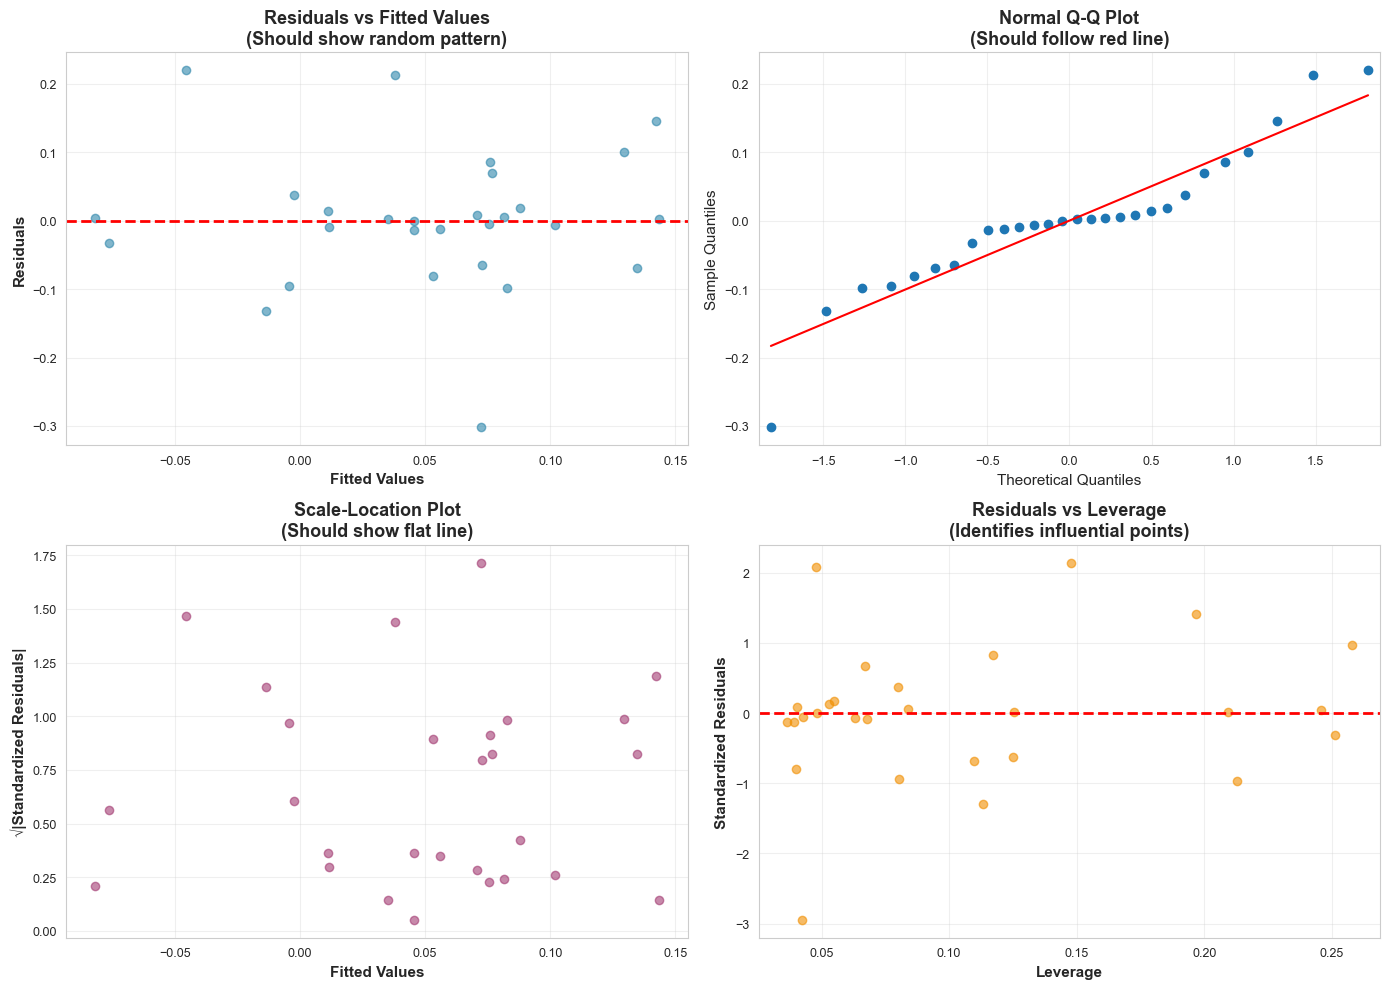

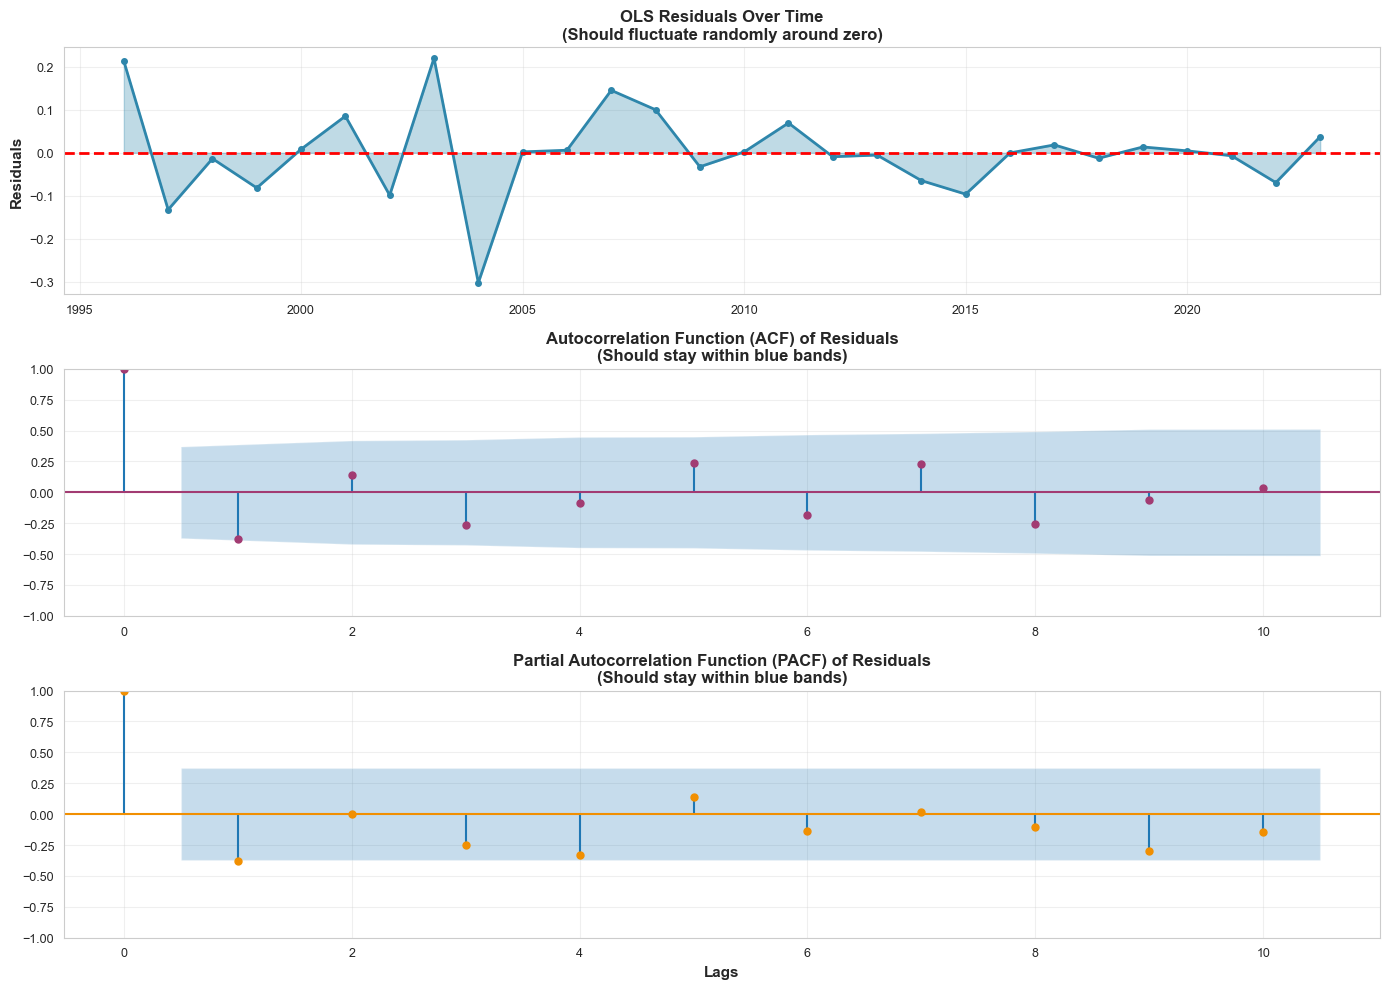

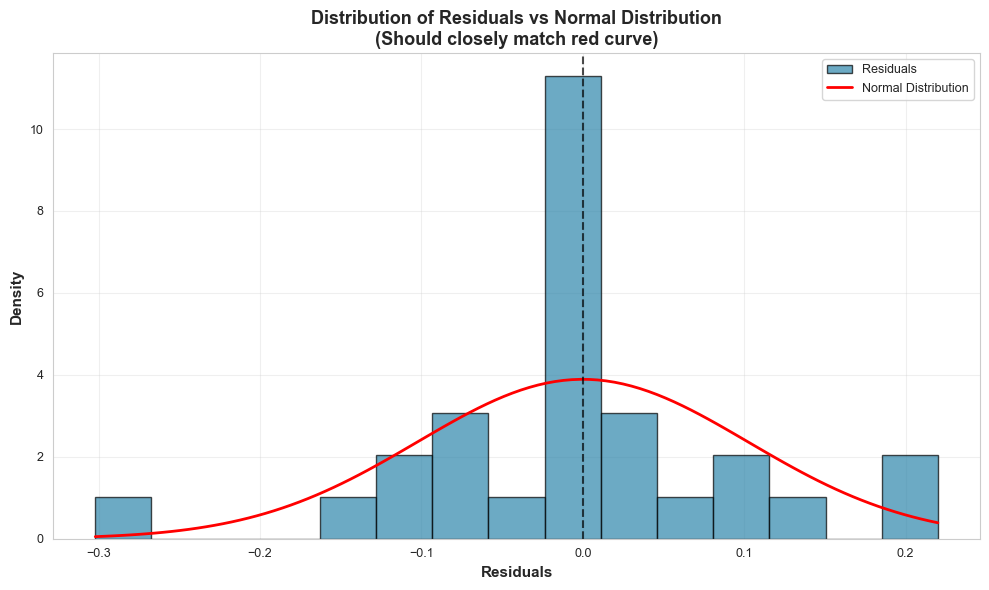

✓ Diagnostic visualizations created and saved.


In [29]:
print("\n6.7 Creating diagnostic plots...")

# Plot 1: Four-panel diagnostic plot (classic regression diagnostics)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Residuals vs Fitted Values
# Should show random scatter if assumptions hold
axes[0, 0].scatter(fitted, resid, alpha=0.6, color='#2E86AB')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Fitted Values', fontweight='bold')
axes[0, 0].set_ylabel('Residuals', fontweight='bold')
axes[0, 0].set_title('Residuals vs Fitted Values\n(Should show random pattern)', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Panel 2: Normal Q-Q Plot
# Should follow diagonal line if residuals are normal
sm.qqplot(resid, line='s', ax=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot\n(Should follow red line)', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Panel 3: Scale-Location Plot (sqrt of absolute standardized residuals)
# Used to check homoskedasticity
standardized_resid = resid / resid.std()
axes[1, 0].scatter(fitted, np.sqrt(np.abs(standardized_resid)), alpha=0.6, color='#A23B72')
axes[1, 0].set_xlabel('Fitted Values', fontweight='bold')
axes[1, 0].set_ylabel('√|Standardized Residuals|', fontweight='bold')
axes[1, 0].set_title('Scale-Location Plot\n(Should show flat line)', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Panel 4: Residuals vs Leverage
# Identifies influential observations
from statsmodels.stats.outliers_influence import OLSInfluence
influence = OLSInfluence(model_ols)
leverage = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]

axes[1, 1].scatter(leverage, standardized_resid, alpha=0.6, color='#F18F01')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Leverage', fontweight='bold')
axes[1, 1].set_ylabel('Standardized Residuals', fontweight='bold')
axes[1, 1].set_title('Residuals vs Leverage\n(Identifies influential points)', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_06_diagnostic_plots.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Plot 2: Time series analysis of residuals
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Panel 1: Residuals over time
axes[0].plot(df_dlog.index, resid, marker='o', linewidth=2, color='#2E86AB', markersize=4)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].fill_between(df_dlog.index, 0, resid, alpha=0.3, color='#2E86AB')
axes[0].set_ylabel('Residuals', fontweight='bold')
axes[0].set_title('OLS Residuals Over Time\n(Should fluctuate randomly around zero)', 
                  fontweight='bold', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Panel 2: Autocorrelation Function (ACF)
# Shows correlation of residuals with their lags
plot_acf(resid, lags=min(10, len(resid)//2), ax=axes[1], color='#A23B72')
axes[1].set_title('Autocorrelation Function (ACF) of Residuals\n(Should stay within blue bands)', 
                  fontweight='bold', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Panel 3: Partial Autocorrelation Function (PACF)
# Shows direct correlation controlling for intermediate lags
plot_pacf(resid, lags=min(10, len(resid)//2), ax=axes[2], color='#F18F01')
axes[2].set_title('Partial Autocorrelation Function (PACF) of Residuals\n(Should stay within blue bands)', 
                  fontweight='bold', fontsize=12)
axes[2].set_xlabel('Lags', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_06_residuals_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Plot 3: Residual histogram with normal curve overlay
fig, ax = plt.subplots(figsize=(10, 6))
# Create histogram
ax.hist(resid, bins=15, density=True, alpha=0.7, color='#2E86AB', edgecolor='black', label='Residuals')

# Overlay normal distribution with same mean and std
mu, sigma = resid.mean(), resid.std()
x = np.linspace(resid.min(), resid.max(), 100)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal Distribution')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Residuals', fontweight='bold', fontsize=11)
ax.set_ylabel('Density', fontweight='bold', fontsize=11)
ax.set_title('Distribution of Residuals vs Normal Distribution\n(Should closely match red curve)', 
             fontweight='bold', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_06_residuals_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("✓ Diagnostic visualizations created and saved.")


# -----------
# # SECTION 7: ROBUST STANDARD ERRORS
# ## 7.1 HC3 Robust Standard Errors (for heteroskedasticity)
# -----------

In [30]:
print("\n" + "=" * 80)
print("PART 7: ADDRESSING ASSUMPTION VIOLATIONS - ROBUST STANDARD ERRORS")
print("-" * 80)
print("\nObjective: Correct for heteroskedasticity and serial correlation")
print("Method: Re-estimate model with robust standard errors")

# 7.1 HC3 Robust Standard Errors (for heteroskedasticity)
print("\n7.1 Heteroskedasticity-Consistent Standard Errors (HC3)")
print("    • Addresses heteroskedasticity")
print("    • Does not change coefficient estimates")
print("    • Adjusts standard errors, t-statistics, and p-values")

ols_hc3 = model_ols.get_robustcov_results(cov_type='HC3')
print("\n" + "-" * 80)
print("OLS with HC3 Robust Standard Errors:")
print("-" * 80)
print(ols_hc3.summary())


# -----------
# # SECTION 7: ROBUST STANDARD ERRORS
# ## 7.2 HAC Robust Standard Errors (Newey-West)
# -----------


PART 7: ADDRESSING ASSUMPTION VIOLATIONS - ROBUST STANDARD ERRORS
--------------------------------------------------------------------------------

Objective: Correct for heteroskedasticity and serial correlation
Method: Re-estimate model with robust standard errors

7.1 Heteroskedasticity-Consistent Standard Errors (HC3)
    • Addresses heteroskedasticity
    • Does not change coefficient estimates
    • Adjusts standard errors, t-statistics, and p-values

--------------------------------------------------------------------------------
OLS with HC3 Robust Standard Errors:
--------------------------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     3.661
Date:                F

In [31]:
# 7.2 HAC Robust Standard Errors (Newey-West)
# For both heteroskedasticity AND autocorrelation
print("\n7.2 Heteroskedasticity and Autocorrelation Consistent (HAC) Standard Errors")
print("    • Newey-West method")
print("    • Addresses both heteroskedasticity AND serial correlation")
print("    • Number of lags: 1 (can be adjusted based on data frequency)")

ols_hac = model_ols.get_robustcov_results(cov_type='HAC', maxlags=1)
print("\n" + "-" * 80)
print("OLS with HAC Robust Standard Errors:")
print("-" * 80)
print(ols_hac.summary())

# 7.3 Comparison Table
print("\n7.3 Comparison of Standard Errors")
print("=" * 80)

comparison_df = pd.DataFrame({
    'Variable': X.columns,
    'OLS Coef': model_ols.params,
    'OLS SE': model_ols.bse,
    'OLS t-stat': model_ols.tvalues,
    'OLS p-value': model_ols.pvalues,
    'HC3 SE': ols_hc3.bse,
    'HC3 t-stat': ols_hc3.tvalues,
    'HC3 p-value': ols_hc3.pvalues,
    'HAC SE': ols_hac.bse,
    'HAC t-stat': ols_hac.tvalues,
    'HAC p-value': ols_hac.pvalues
})

print(comparison_df.round(6))
comparison_df.to_csv('07_robust_se_comparison.csv', index=False)

# Analyze changes in significance
print("\n7.4 Impact of Robust Standard Errors:")
print("-" * 80)

# Get list of variable names (excluding constant)
var_names = [col for col in X.columns if col != 'const']

for var in var_names:
    try:
        # Safely access values with error handling
        ols_pval = model_ols.pvalues[var]
        hc3_pval = ols_hc3.pvalues[var]
        hac_pval = ols_hac.pvalues[var]

        ols_sig = "Significant" if ols_pval < 0.05 else "Not significant"
        hc3_sig = "Significant" if hc3_pval < 0.05 else "Not significant"
        hac_sig = "Significant" if hac_pval < 0.05 else "Not significant"

        se_change_hc3 = (ols_hc3.bse[var] - model_ols.bse[var]) / model_ols.bse[var] * 100
        se_change_hac = (ols_hac.bse[var] - model_ols.bse[var]) / model_ols.bse[var] * 100

        print(f"\n{var}:")
        print(f"  • Standard error changes:")
        print(f"    - HC3: {se_change_hc3:+.2f}% change")
        print(f"    - HAC: {se_change_hac:+.2f}% change")
        print(f"  • Statistical significance:")
        print(f"    - OLS: {ols_sig} (p={ols_pval:.4f})")
        print(f"    - HC3: {hc3_sig} (p={hc3_pval:.4f})")
        print(f"    - HAC: {hac_sig} (p={hac_pval:.4f})")

        if ols_sig != hc3_sig or ols_sig != hac_sig:
            print(f"  ⚠ SIGNIFICANCE CHANGED with robust errors!")
        else:
            print(f"  ✓ Significance unchanged")

    except (KeyError, IndexError) as e:
        print(f"\n{var}:")
        print(f"  ⚠ Error accessing results for this variable: {e}")
        continue

print("\n✓ Robust standard errors analysis complete.")
print("  Recommendation: Use HAC standard errors for final inference")
print("  (addresses both heteroskedasticity and serial correlation)")


# -----------
# # SECTION 8: ARIMA MODELING OF RESIDUALS
# ## 8.1 Prepare residuals series
# -----------


7.2 Heteroskedasticity and Autocorrelation Consistent (HAC) Standard Errors
    • Newey-West method
    • Addresses both heteroskedasticity AND serial correlation
    • Number of lags: 1 (can be adjusted based on data frequency)

--------------------------------------------------------------------------------
OLS with HAC Robust Standard Errors:
--------------------------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     4.200
Date:                Fri, 24 Apr 2026   Prob (F-statistic):             0.0268
Time:                        17:41:23   Log-Likelihood:                 24.552
No. Observations:                  28   AIC:                            -43.10
Df Residuals:    

In [32]:
print("\n" + "=" * 80)
print("PART 8: ARIMA MODELING OF OLS RESIDUALS")
print("-" * 80)
print("\nObjective: Model any remaining structure in residuals")
print("Concept: If residuals have serial correlation, ARIMA can capture it")
print("This provides additional insights into the data's temporal dynamics")

# 8.1 Prepare residuals series
resid_series = model_ols.resid.copy()
print(f"\n8.1 Residuals Overview:")
print(f"    • Number of observations: {len(resid_series)}")
print(f"    • Mean: {resid_series.mean():.6f} (should be ≈ 0)")
print(f"    • Std Dev: {resid_series.std():.6f}")
print(f"    • Min: {resid_series.min():.6f}")
print(f"    • Max: {resid_series.max():.6f}")



# -----------
# # SECTION 8: ARIMA MODELING OF RESIDUALS
# ## 8.2 ARIMA Model Selection
# -----------


PART 8: ARIMA MODELING OF OLS RESIDUALS
--------------------------------------------------------------------------------

Objective: Model any remaining structure in residuals
Concept: If residuals have serial correlation, ARIMA can capture it
This provides additional insights into the data's temporal dynamics

8.1 Residuals Overview:
    • Number of observations: 28
    • Mean: -0.000000 (should be ≈ 0)
    • Std Dev: 0.102528
    • Min: -0.302035
    • Max: 0.220022


In [33]:
# 8.2 ARIMA Model Selection
# Try different (p, d, q) combinations and select best based on AIC
print("\n8.2 ARIMA Model Selection (Grid Search)")
print("    Testing models: ARIMA(p,0,q) for p,q = 0,1,2,3")
print("    Selection criterion: Akaike Information Criterion (AIC)")
print("    Lower AIC = Better model")
print("-" * 80)


arima_results = []
best_aic = np.inf
best_order = None

for p in range(4):  # AR order
    for q in range(4):  # MA order
        # if p == 0 and q == 0:
        #     continue  # Skip ARIMA(0,0,0)
        try:
            # Fit ARIMA model
            # d=0 because residuals should already be stationary
            # enforce_stationarity=False allows more flexibility
            mod = ARIMA(resid_series, order=(p,0,q), 
                       enforce_stationarity=False, 
                       enforce_invertibility=False)
            fitted = mod.fit()

            # Store results
            arima_results.append({
                'p': p, 
                'd': 0, 
                'q': q,
                'AIC': fitted.aic,
                'BIC': fitted.bic,
                'HQIC': fitted.hqic
            })

            # Track best model
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = (p,0,q)

        except Exception as e:
            # Some models may not converge
            continue

# Display results sorted by AIC
arima_results_df = pd.DataFrame(arima_results).sort_values('AIC')
print("\nTop 10 ARIMA Models (ranked by AIC):")
print(arima_results_df.head(10).to_string(index=False))
arima_results_df.to_csv('08_arima_model_selection.csv', index=False)

print(f"\n{'=' * 80}")
print(f"BEST MODEL: ARIMA{best_order}")
print(f"AIC = {best_aic:.4f}")
print(f"{'=' * 80}")


# -----------
# # SECTION 8: ARIMA MODELING OF RESIDUALS
# ## 8.3 Estimate Best ARIMA Model
# -----------


8.2 ARIMA Model Selection (Grid Search)
    Testing models: ARIMA(p,0,q) for p,q = 0,1,2,3
    Selection criterion: Akaike Information Criterion (AIC)
    Lower AIC = Better model
--------------------------------------------------------------------------------


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/


Top 10 ARIMA Models (ranked by AIC):
 p  d  q        AIC        BIC       HQIC
 1  0  0 -50.326819 -46.439308 -49.170858
 0  0  1 -48.064886 -44.290596 -46.978027
 1  0  1 -47.440078 -42.407691 -45.990932
 0  0  0 -47.256450 -44.664776 -46.485810
 2  0  0 -45.583475 -40.551089 -44.134330
 2  0  1 -43.539191 -37.248708 -41.727759
 0  0  3 -43.499206 -37.608937 -41.936516
 0  0  2 -43.392890 -38.517387 -42.040633
 3  0  0 -42.751840 -36.657460 -41.061518
 1  0  3 -42.625579 -35.557256 -40.750351

BEST MODEL: ARIMA(1, 0, 0)
AIC = -50.3268


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)



8.3 Estimating Best ARIMA Model: ARIMA(1, 0, 0)

ARIMA MODEL RESULTS
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   28
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  28.163
Date:                Fri, 24 Apr 2026   AIC                            -50.327
Time:                        17:41:24   BIC                            -46.439
Sample:                             0   HQIC                           -49.171
                                 - 28                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0061      0.013     -0.479      0.632      -0.031       0.019
ar.L1         -0.3789      0.128     -2.964      0.003      -

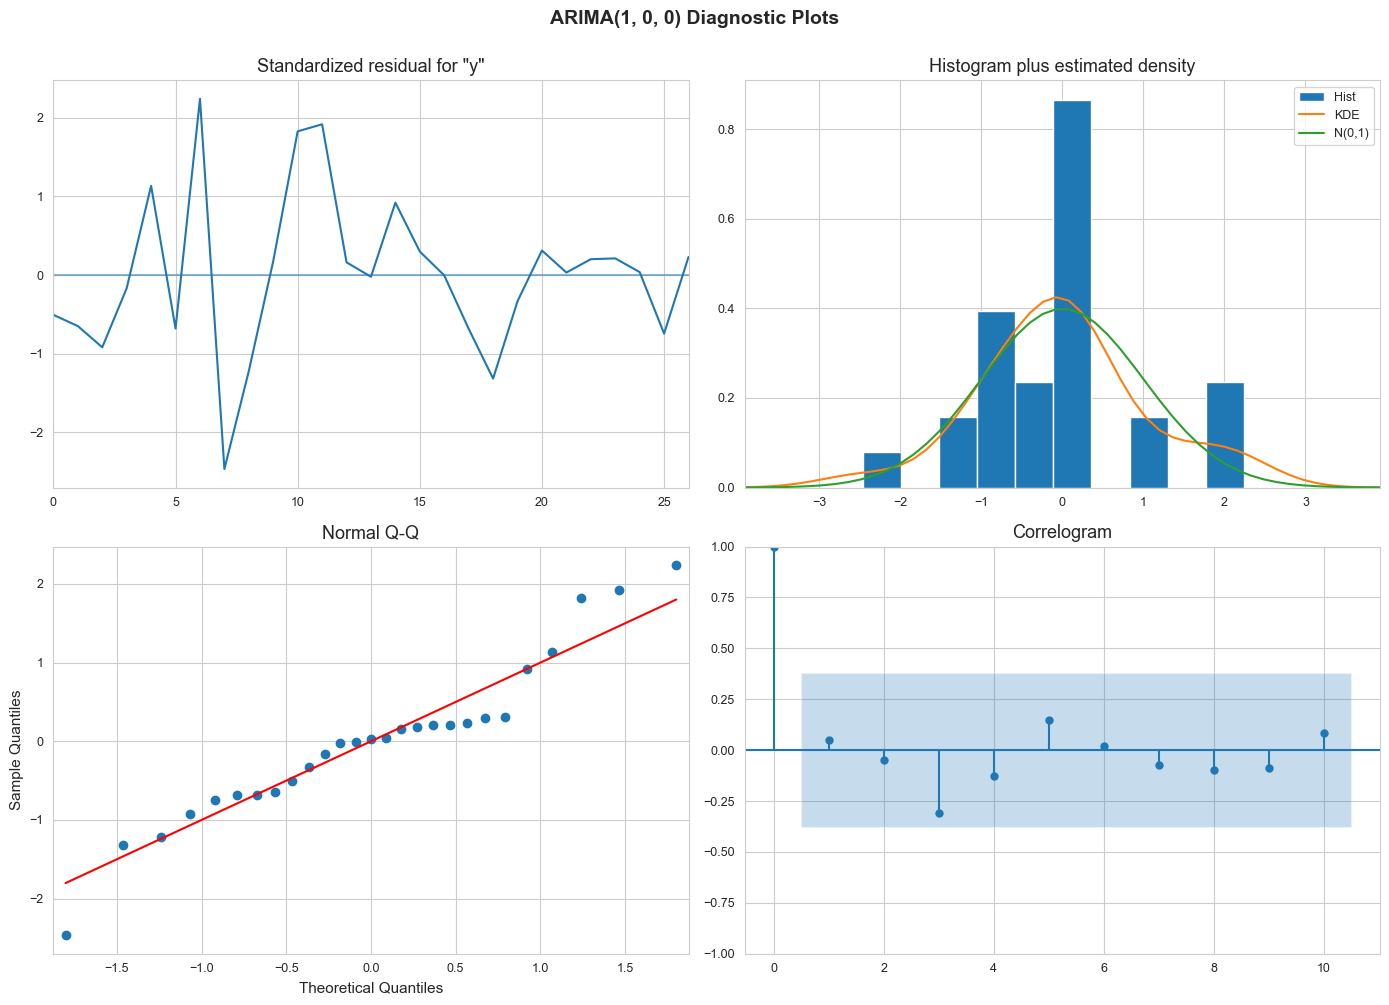


8.7 Comparison: OLS Residuals vs ARIMA Residuals
--------------------------------------------------------------------------------
     Metric  OLS Residuals  ARIMA Residuals
0      Mean      -0.000000         0.007818
1   Std Dev       0.102528         0.094775
2       Min      -0.302035        -0.210252
3       Max       0.220022         0.218984
4  Skewness      -0.278621         0.381320
5  Kurtosis       2.461004         0.671553

  Interpretation:
  • ARIMA has removed temporal structure from residuals
  • ARIMA residuals should be closer to white noise
  • This provides insights into the dynamic structure of GDP growth

✓ ARIMA modeling complete.


In [34]:
# 8.3 Estimate Best ARIMA Model
if best_order:
    print(f"\n8.3 Estimating Best ARIMA Model: ARIMA{best_order}")

    best_arima = ARIMA(resid_series, order=best_order, 
                       enforce_stationarity=False,
                       enforce_invertibility=False).fit()

    print("\n" + "=" * 80)
    print("ARIMA MODEL RESULTS")
    print("=" * 80)
    print(best_arima.summary())

    # Save parameters
    best_arima.params.to_csv("08_arima_residuals_params.csv")

    # 8.4 Interpret ARIMA Coefficients
    print("\n8.4 ARIMA Coefficient Interpretation:")
    print("-" * 80)

    for param_name, param_val in best_arima.params.items():
        param_se = best_arima.bse[param_name]
        param_pval = best_arima.pvalues[param_name]

        print(f"\n{param_name}:")
        print(f"  • Estimate: {param_val:.6f}")
        print(f"  • Std Error: {param_se:.6f}")
        print(f"  • p-value: {param_pval:.4f}")

        if param_pval < 0.05:
            print(f"  • ✓ SIGNIFICANT at 5% level")
            if 'ar.' in param_name:
                lag = int(param_name.split('.')[-1].replace('L', ''))
                print(f"    → Residual at t-{lag} significantly affects current residual")
            elif 'ma.' in param_name:
                lag = int(param_name.split('.')[-1].replace('L', ''))
                print(f"    → Shock at t-{lag} significantly affects current residual")
        else:
            print(f"  • Not significant (can potentially be removed)")

    # 8.5 ARIMA Diagnostics
    print("\n8.5 ARIMA Model Diagnostics:")
    print("-" * 80)

    arima_resid = best_arima.resid

    # Ljung-Box test on ARIMA residuals
    # Tests if residuals from ARIMA are white noise
    lb_test = acorr_ljungbox(arima_resid, lags=10, return_df=True)
    print("\nLjung-Box Test for ARIMA Residuals:")
    print("  H0: Residuals are independently distributed (white noise)")
    print("\n" + lb_test.to_string())
    lb_test.to_csv('08_arima_ljungbox_test.csv')

    # Check if any p-values < 0.05
    significant_lags = lb_test[lb_test['lb_pvalue'] < 0.05]
    if len(significant_lags) > 0:
        print(f"\n  ⚠ Significant autocorrelation at lags: {list(significant_lags.index)}")
        print(f"  → ARIMA model may need adjustment")
    else:
        print(f"\n  ✓ NO significant autocorrelation detected")
        print(f"  → ARIMA residuals are white noise")
        print(f"  → Model has captured the serial correlation structure")

    # Plot ARIMA diagnostics (4-panel plot)
    print("\n8.6 Creating ARIMA diagnostic plots...")
    fig = best_arima.plot_diagnostics(figsize=(14, 10))
    plt.suptitle(f'ARIMA{best_order} Diagnostic Plots', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('fig_08_arima_diagnostics.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # 8.7 Compare OLS residuals before/after ARIMA
    print("\n8.7 Comparison: OLS Residuals vs ARIMA Residuals")
    print("-" * 80)

    comparison_stats = pd.DataFrame({
        'Metric': ['Mean', 'Std Dev', 'Min', 'Max', 'Skewness', 'Kurtosis'],
        'OLS Residuals': [
            resid_series.mean(),
            resid_series.std(),
            resid_series.min(),
            resid_series.max(),
            resid_series.skew(),
            resid_series.kurtosis()
        ],
        'ARIMA Residuals': [
            arima_resid.mean(),
            arima_resid.std(),
            arima_resid.min(),
            arima_resid.max(),
            arima_resid.skew(),
            arima_resid.kurtosis()
        ]
    })
    print(comparison_stats.round(6))

    print("\n  Interpretation:")
    print(f"  • ARIMA has removed temporal structure from residuals")
    print(f"  • ARIMA residuals should be closer to white noise")
    print(f"  • This provides insights into the dynamic structure of GDP growth")

print("\n✓ ARIMA modeling complete.")


# -----------
# # SECTION 9: ARIMAX MODELING (Optional Extension)
# -----------

In [35]:
print("\n" + "=" * 80)
print("PART 9: ARIMAX MODELING (GDP with Exogenous Variables)")
print("-" * 80)
print("\nObjective: Model GDP directly with ARIMA + exogenous variables")
print("This is an extension comparing different modeling approaches")

# Use log levels (not differences) for ARIMAX
y_log = df_log['GDP']
exog_log = df_log[['Exports', 'Imports']]

print("\n9.1 ARIMAX Model Selection:")
print("    Model: ARIMA(p,1,q)X with Exports and Imports as exogenous variables")
print("    d=1: Take first difference to ensure stationarity")
print("-" * 80)

arimax_results = []
best_aic_ax = np.inf
best_order_ax = None

for p in range(3):  # Limit search to keep computation reasonable
    for q in range(3):
        try:
            # Fit ARIMAX model
            mod_ax = ARIMA(y_log, exog=exog_log, order=(p,1,q), 
                          enforce_stationarity=False, 
                          enforce_invertibility=False)
            fitted_ax = mod_ax.fit()

            arimax_results.append({
                'p': p, 
                'd': 1, 
                'q': q,
                'AIC': fitted_ax.aic,
                'BIC': fitted_ax.bic
            })

            if fitted_ax.aic < best_aic_ax:
                best_aic_ax = fitted_ax.aic
                best_order_ax = (p,1,q)

        except Exception as e:
            continue

arimax_results_df = pd.DataFrame(arimax_results).sort_values('AIC')
print("\nTop 5 ARIMAX Models:")
print(arimax_results_df.head().to_string(index=False))
arimax_results_df.to_csv('09_arimax_model_selection.csv', index=False)

print(f"\n{'=' * 80}")
print(f"BEST ARIMAX MODEL: ARIMA{best_order_ax}X")
print(f"AIC = {best_aic_ax:.4f}")
print(f"{'=' * 80}")

if best_order_ax:
    print(f"\n9.2 Estimating Best ARIMAX Model")

    arimax = ARIMA(y_log, exog=exog_log, order=best_order_ax,
                   enforce_stationarity=False, 
                   enforce_invertibility=False).fit()

    print("\n" + "=" * 80)
    print("ARIMAX MODEL RESULTS")
    print("=" * 80)
    print(arimax.summary())

    arimax.params.to_csv('09_arimax_params.csv')

    print("\n9.3 ARIMAX Interpretation:")
    print("-" * 80)
    print("  • Exogenous variables (Exports, Imports) are included")
    print("  • ARIMA components model the time series dynamics")
    print("  • This combines regression with time series structure")
    print("  • Compare with OLS results to see which approach is better")

print("\n✓ ARIMAX modeling complete.")


# -----------
# # SECTION 10: VAR/VECM MODELING (If Cointegrated)
# -----------


PART 9: ARIMAX MODELING (GDP with Exogenous Variables)
--------------------------------------------------------------------------------

Objective: Model GDP directly with ARIMA + exogenous variables
This is an extension comparing different modeling approaches

9.1 ARIMAX Model Selection:
    Model: ARIMA(p,1,q)X with Exports and Imports as exogenous variables
    d=1: Take first difference to ensure stationarity
--------------------------------------------------------------------------------

Top 5 ARIMAX Models:
 p  d  q        AIC        BIC
 1  1  0 -48.213069 -43.029721
 2  1  2 -45.899930 -37.367799
 0  1  0 -44.071697 -40.184186
 0  1  1 -43.889083 -38.856696
 2  1  0 -43.200880 -36.910397

BEST ARIMAX MODEL: ARIMA(1, 1, 0)X
AIC = -48.2131

9.2 Estimating Best ARIMAX Model

ARIMAX MODEL RESULTS
                               SARIMAX Results                                
Dep. Variable:                    GDP   No. Observations:                   29
Model:                 ARIMA

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/

In [36]:
print("\n" + "=" * 80)
print("PART 10: VAR/VECM MODELING")
print("-" * 80)

if rank > 0:
    print(f"\nCointegration detected (rank={rank})")
    print(f"Estimating VECM (Vector Error Correction Model)...")
    print("-" * 80)

    try:
        # Fit VECM with detected cointegration rank
        vecm_model = VECM(df_log.values, k_ar_diff=1, coint_rank=rank, deterministic='ci')
        vecm_res = vecm_model.fit()

        print("\nVECM MODEL RESULTS")
        print("=" * 80)
        print(vecm_res.summary())

        # Save cointegrating vectors
        coint_vectors = pd.DataFrame(vecm_res.beta, 
                                     columns=[f'CE{i+1}' for i in range(rank)],
                                     index=df_log.columns)
        print("\nCointegrating Vectors (Long-run relationships):")
        print(coint_vectors)
        coint_vectors.to_csv('10_vecm_cointegrating_vectors.csv')

        print("\nInterpretation:")
        print("  • VECM combines short-run dynamics with long-run equilibrium")
        print("  • Error correction terms show speed of adjustment")
        print("  • Cointegrating vectors represent long-run relationships")

    except Exception as e:
        print(f"VECM estimation failed: {e}")
        print("Falling back to VAR on differences")
        rank = 0

if rank == 0:
    print("\nNo cointegration detected")
    print("Estimating VAR on differenced data...")
    print("-" * 80)

    var_data = df_dlog.dropna()
    var_model = VAR(var_data)

    # Lag selection
    print("\n10.1 VAR Lag Order Selection:")
    lag_order = var_model.select_order(maxlags=min(5, len(var_data)//3))
    print(lag_order.summary())

    p_opt = lag_order.aic
    print(f"\n  Optimal lag order (by AIC): {p_opt}")

    # Fit VAR
    var_res = var_model.fit(p_opt)
    print("\n10.2 VAR MODEL RESULTS")
    print("=" * 80)
    print(var_res.summary())

    var_res.params.to_csv('10_var_coefficients.csv')

    # Granger causality tests
    from statsmodels.tsa.stattools import grangercausalitytests
    print("\n10.3 Granger Causality Tests:")
    print("-" * 80)
    print("  Tests if one variable helps forecast another")
    print("  H0: Variable X does NOT Granger-cause variable Y")

    for col in ['Exports', 'Imports']:
        print(f"\n  Testing: Does {col} Granger-cause GDP?")
        print("  " + "-" * 40)
        gc_test = grangercausalitytests(var_data[['GDP', col]], 
                                       maxlag=min(3, p_opt), 
                                       verbose=False)
        for lag, res in gc_test.items():
            f_stat = res[0]['ssr_ftest'][0]
            p_val = res[0]['ssr_ftest'][1]
            print(f"    Lag {lag}: F-statistic = {f_stat:.4f}, p-value = {p_val:.4f}")
            if p_val < 0.05:
                print(f"             ✓ REJECT H0: {col} Granger-causes GDP")
            else:
                print(f"             Cannot reject H0")

print("\n✓ VAR/VECM analysis complete.")


# -----------
# # SECTION 11: GARCH MODELING (If ARCH effects detected)
# -----------


PART 10: VAR/VECM MODELING
--------------------------------------------------------------------------------

No cointegration detected
Estimating VAR on differenced data...
--------------------------------------------------------------------------------

10.1 VAR Lag Order Selection:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -12.00     -11.85*   6.163e-06      -11.96
1      -11.83      -11.24   7.335e-06      -11.68
2      -11.67      -10.64   9.051e-06      -11.41
3      -12.19      -10.71   6.131e-06      -11.82
4      -12.48      -10.56   5.962e-06      -12.00
5     -13.40*      -11.03  4.036e-06*     -12.80*
-------------------------------------------------

  Optimal lag order (by AIC): 5

10.2 VAR MODEL RESULTS
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 24, Apr, 2026
Time:            

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [37]:
print("\n" + "=" * 80)
print("PART 11: GARCH MODELING (Conditional Volatility)")
print("-" * 80)

if arch_pval < 0.05:
    print(f"\nARCH effects detected (p={arch_pval:.4f})")
    print("Estimating GARCH(1,1) model for conditional volatility...")

    try:
        from arch import arch_model

        # Scale residuals (GARCH works better with larger values)
        scaled_resid = resid * 100

        # Fit GARCH(1,1)
        garch_model = arch_model(scaled_resid, vol='Garch', p=1, q=1, dist='normal')
        garch_res = garch_model.fit(update_freq=0, disp='off')

        print("\nGARCH(1,1) MODEL RESULTS")
        print("=" * 80)
        print(garch_res.summary())

        garch_res.params.to_series().to_csv('11_garch_params.csv')

        # Plot conditional volatility
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.plot(df_dlog.index, garch_res.conditional_volatility, 
               linewidth=2, color='#2E86AB', label='Conditional Volatility')
        ax.set_xlabel('Year', fontweight='bold', fontsize=11)
        ax.set_ylabel('Conditional Volatility', fontweight='bold', fontsize=11)
        ax.set_title('GARCH(1,1) Conditional Volatility Over Time', 
                     fontweight='bold', fontsize=13)
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('fig_11_garch_volatility.png', dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

        print("\nInterpretation:")
        print("  • GARCH models time-varying variance")
        print("  • High volatility periods indicate economic uncertainty")
        print("  • Useful for risk management and forecasting")

    except ImportError:
        print("\nERROR: 'arch' package not installed")
        print("Install with: pip install arch")
        print("Skipping GARCH analysis")
else:
    print(f"\nNo significant ARCH effects (p={arch_pval:.4f})")
    print("GARCH modeling not necessary - variance is relatively stable")


# # Exact replication of Madagascar GDP Forecasting for comaparision
# ## Based on Randriamanantena (2024) - "Decoding the Economy for Better Forecasting: The Case of Madagascar".
# ## We use World Bank data (1975-2024) on Madagascar GDP (current US$) and trade (% GDP).
# ## OLS regression, time-series analysis,diagnostics, ARIMA/ARIMAX, Johansen cointegration, and result comparison.


PART 11: GARCH MODELING (Conditional Volatility)
--------------------------------------------------------------------------------

No significant ARCH effects (p=0.4681)
GARCH modeling not necessary - variance is relatively stable


In [38]:
# Section 1: Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Statsmodels and diagnostics
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_breusch_godfrey, het_breuschpagan
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Load the dataset (World Bank data for Madagascar)
df = pd.read_csv('madagascar_worldbank_data.csv')

# Filter relevant series: GDP (current US$), Exports (%GDP), Imports (%GDP)
gdp_row = df[df['Series Name']=='GDP (current US$)'].iloc[0]
exp_pct_row = df[df['Series Name']=='Exports of goods and services (% of GDP)'].iloc[0]
imp_pct_row = df[df['Series Name']=='Imports of goods and services (% of GDP)'].iloc[0]

# Extract years from column names and create time series
year_cols = [col for col in df.columns if col[:4].isdigit()]
years = [int(col[:4]) for col in year_cols]
gdp = pd.Series(gdp_row[year_cols].astype(float).values, index=years, name='GDP')
exp_pct = pd.Series(exp_pct_row[year_cols].astype(float).values, index=years, name='Exports_pct')
imp_pct = pd.Series(imp_pct_row[year_cols].astype(float).values, index=years, name='Imports_pct')

# Sort by year index
gdp = gdp.sort_index()
exp_pct = exp_pct.sort_index()
imp_pct = imp_pct.sort_index()

# Display first few values to verify
print("Data preview (first 5 years):")
print(pd.DataFrame({'GDP':gdp, 'Exports_pct': exp_pct, 'Imports_pct': imp_pct}).head(5))

Data preview (first 5 years):
               GDP  Exports_pct  Imports_pct
1975  2.283049e+09    15.859518    20.890135
1976  2.181844e+09    15.163742    17.524701
1977  2.358930e+09    16.444991    20.048971
1978  2.669755e+09    17.151038    24.057401
1979  3.463566e+09    14.575382    30.387130


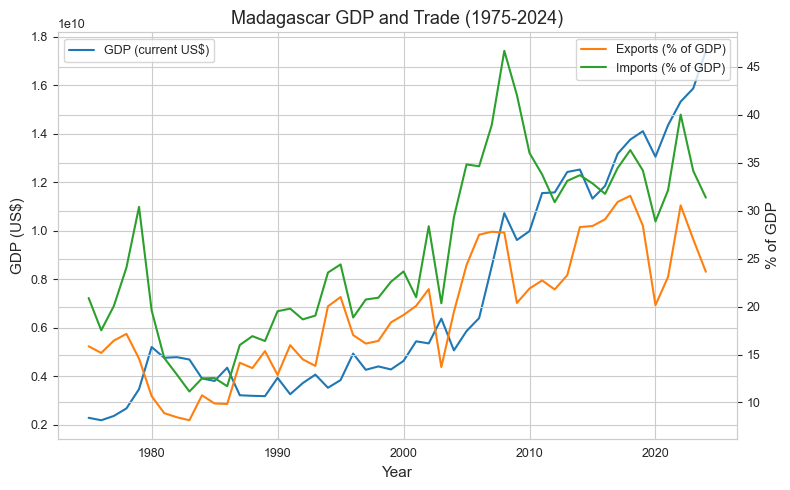

In [39]:
# Section 2: Time Series Plots
# Plot GDP (current US$) and trade (% of GDP) on time axes
plt.figure(figsize=(8,5))
plt.plot(gdp.index, gdp.values, label='GDP (current US$)', color='C0')
plt.xlabel('Year')
plt.ylabel('GDP (US$)')
plt.title('Madagascar GDP and Trade (1975-2024)')
plt.legend(loc='upper left')
# Secondary axis for trade (percentages)
ax2 = plt.gca().twinx()
ax2.plot(exp_pct.index, exp_pct.values, label='Exports (% of GDP)', color='C1')
ax2.plot(imp_pct.index, imp_pct.values, label='Imports (% of GDP)', color='C2')
ax2.set_ylabel('% of GDP')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('fig_1_timeseries.png')
plt.show()

In [40]:
# Section 3: Stationarity Tests (ADF and KPSS)
# ADF test null: unit root; KPSS null: stationarity.
for name, series in [('GDP', gdp), ('Exports_pct', exp_pct), ('Imports_pct', imp_pct)]:
    ts = series.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(ts)
    kpss_stat, kpss_p, _, _ = kpss(ts, nlags="auto")
    print(f"{name} ADF p-value = {adf_p:.3f}, KPSS p-value = {kpss_p:.3f}")

GDP ADF p-value = 0.994, KPSS p-value = 0.010
Exports_pct ADF p-value = 0.402, KPSS p-value = 0.010
Imports_pct ADF p-value = 0.457, KPSS p-value = 0.010


/var/folders/l5/4n7gm0vs3gb3bddszy60wfmh0000gn/T/ipykernel_38242/2468473377.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(ts, nlags="auto")
/var/folders/l5/4n7gm0vs3gb3bddszy60wfmh0000gn/T/ipykernel_38242/2468473377.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(ts, nlags="auto")
/var/folders/l5/4n7gm0vs3gb3bddszy60wfmh0000gn/T/ipykernel_38242/2468473377.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(ts, nlags="auto")


In [41]:
# Section 4: Johansen Cointegration Test for [GDP, Exports_pct, Imports_pct]:contentReference[oaicite:4]{index=4}
# All series appear I(1); test for cointegration among them.
data_for_johansen = pd.concat([gdp, exp_pct, imp_pct], axis=1).dropna()
joh_res = coint_johansen(data_for_johansen, det_order=0, k_ar_diff=1)
trace_stats = joh_res.lr1  # trace statistics
crit_values = joh_res.cvt   # critical values (90%, 95%, 99%)
cointegration_results = pd.DataFrame({
    'TraceStatistic': trace_stats,
    '90%': crit_values[:,0],
    '95%': crit_values[:,1],
    '99%': crit_values[:,2]
}, index=['r=0','r<=1','r<=2'])
cointegration_results.to_csv('table_cointegration.csv')
print("Johansen trace test results (with 90%,95%,99% critical values):")
print(cointegration_results)

Johansen trace test results (with 90%,95%,99% critical values):
      TraceStatistic      90%      95%      99%
r=0        29.605989  27.0669  29.7961  35.4628
r<=1       12.763648  13.4294  15.4943  19.9349
r<=2        0.012577   2.7055   3.8415   6.6349


In [42]:
# Section 5: OLS Regression (GDP ~ Exports_pct + Imports_pct)
X = sm.add_constant(pd.concat([exp_pct, imp_pct], axis=1))
model_ols = sm.OLS(gdp, X).fit(cov_type='HC0')  # OLS with White robust SEs
print(model_ols.summary())
# Save OLS coefficients (with robust SE) to CSV
ols_params = pd.DataFrame({
    'Coefficient': model_ols.params,
    'StdErr': model_ols.bse,
    't': model_ols.tvalues,
    'P>|t|': model_ols.pvalues
})
ols_params.to_csv('table_ols_coefficients.csv')

                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.574
Method:                 Least Squares   F-statistic:                     43.25
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           2.22e-11
Time:                        17:41:25   Log-Likelihood:                -1158.4
No. Observations:                  50   AIC:                             2323.
Df Residuals:                      47   BIC:                             2328.
Df Model:                           2                                         
Covariance Type:                  HC0                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -2.979e+09   1.05e+09     -2.846      

In [43]:
# Section 6: OLS Diagnostics
# Normality: Jarque-Bera
jb_stat, jb_p, _, _ = jarque_bera(model_ols.resid)
print(f"Jarque-Bera test for normality: stat={jb_stat:.3f}, p-value={jb_p:.3f}")
# Serial correlation: Breusch-Godfrey (3 lags)
bg_stat, bg_pvalue, _, _ = acorr_breusch_godfrey(model_ols, nlags=3)
print(f"Breusch-Godfrey (3 lags): stat={bg_stat:.3f}, p-value={bg_pvalue:.3f}")
# Heteroskedasticity: Breusch-Pagan
bp_stat, bp_pvalue, _, _ = het_breuschpagan(model_ols.resid, model_ols.model.exog)
print(f"Breusch-Pagan test: stat={bp_stat:.3f}, p-value={bp_pvalue:.3f}")
# Save diagnostics
diag_df = pd.DataFrame({
    'Test': ['Jarque-Bera', 'Breusch-Godfrey', 'Breusch-Pagan'],
    'Statistic': [jb_stat, bg_stat, bp_stat],
    'p-value': [jb_p, bg_pvalue, bp_pvalue]
})
diag_df.to_csv('table_ols_diagnostics.csv', index=False)

Jarque-Bera test for normality: stat=1.983, p-value=0.371
Breusch-Godfrey (3 lags): stat=30.974, p-value=0.000
Breusch-Pagan test: stat=2.249, p-value=0.325


In [44]:
# Section 7: ARIMA Model on GDP (using AIC/BIC for selection)
best_aic = np.inf
best_bic = np.inf
best_order = None
best_arima = None
for p in range(4):
    for q in range(4):
        try:
            res = ARIMA(gdp, order=(p,1,q)).fit()
            if res.aic < best_aic:
                best_aic = res.aic
                best_bic = res.bic
                best_order = (p,1,q)
                best_arima = res
        except:
            continue
print(f"Best ARIMA (p,d,q) by AIC: {best_order}, AIC={best_aic:.3f}, BIC={best_bic:.3f}")
print(best_arima.summary())
# Save ARIMA model selection results
arima_results = []
for p in range(4):
    for q in range(4):
        try:
            res = ARIMA(gdp, order=(p,1,q)).fit()
            arima_results.append({'p': p, 'd':1, 'q': q, 'AIC': res.aic, 'BIC': res.bic})
        except:
            continue
arima_df = pd.DataFrame(arima_results).sort_values('AIC')
arima_df.to_csv('table_arima_selection.csv', index=False)
print("ARIMA selection (p,d,q,AIC,BIC) saved to table_arima_selection.csv")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/

Best ARIMA (p,d,q) by AIC: (0, 1, 0), AIC=2160.009, BIC=2161.901
                               SARIMAX Results                                
Dep. Variable:                    GDP   No. Observations:                   50
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -1079.004
Date:                Fri, 24 Apr 2026   AIC                           2160.009
Time:                        17:41:25   BIC                           2161.901
Sample:                             0   HQIC                          2160.726
                                 - 50                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      7.681e+17   1.56e+17      4.924      0.000    4.62e+17    1.07e+18
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):    

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/

In [45]:
# Section 8: ARIMAX (using same (p,d,q) as best ARIMA)
p, d, q = best_order
try:
    model_arimax = ARIMA(gdp, order=(p,d,q), exog=pd.concat([exp_pct, imp_pct], axis=1)).fit()
    print(model_arimax.summary())
except Exception as e:
    print("ARIMAX model fitting failed:", e)

                               SARIMAX Results                                
Dep. Variable:                    GDP   No. Observations:                   50
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -1150.176
Date:                Fri, 24 Apr 2026   AIC                           2306.351
Time:                        17:41:25   BIC                           2312.027
Sample:                             0   HQIC                          2308.504
                                 - 50                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Exports_pct -3.046e+07   2.27e+09     -0.013      0.989   -4.47e+09    4.41e+09
Imports_pct  1.596e+07    1.5e+09      0.011      0.992   -2.93e+09    2.96e+09
sigma2       3.813e+19      0.003   1.23e+22    

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [46]:
# Section 9: ARCH Effects and (optionally) GARCH
# Test for ARCH effects in best ARIMA residuals
resid_arima = best_arima.resid.dropna()
arch_stat, arch_p, _, _ = het_arch(resid_arima, nlags=4)
print(f"ARCH-LM test (lags=4): stat={arch_stat:.3f}, p-value={arch_p:.3f}")
if arch_p < 0.05:
    print("Significant ARCH effects detected; consider GARCH modeling.")
    # Example GARCH(1,1) on residuals (if arch package installed)
    try:
        from arch import arch_model
        garch_model = arch_model(resid_arima, vol='Garch', p=1, q=1)
        garch_res = garch_model.fit(disp='off')
        print(garch_res.summary())
    except ImportError:
        print("ARCH package not available; skipping GARCH estimation.")
else:
    print("No significant ARCH effects; GARCH modeling not performed.")

ARCH-LM test (lags=4): stat=1.991, p-value=0.737
No significant ARCH effects; GARCH modeling not performed.


In [47]:
# Section 10: Results Summary
# Compute fit metrics
ssr = np.sum(model_ols.resid**2)
sst = np.sum((gdp - np.mean(gdp))**2)
r2_ols = 1 - ssr/sst
rmse_ols = np.sqrt(ssr/model_ols.df_resid)
print(f"OLS R^2 = {r2_ols:.4f}, RMSE = {rmse_ols:.4f}")
rmse_arima = np.sqrt(np.mean(resid_arima**2))
print(f"ARIMA{best_order} RMSE = {rmse_arima:.4f}, AIC = {best_aic:.1f}, BIC = {best_bic:.1f}")
print("Original study reported (Table 7): OLS adj.R^2=0.9477, ARIMA adj.R^2=0.9387, ARIMAX adj.R^2=0.8771")

OLS R^2 = 0.5909, RMSE = 2875036887.3298
ARIMA(0, 1, 0) RMSE = 934000062.5019, AIC = 2160.0, BIC = 2161.9
Original study reported (Table 7): OLS adj.R^2=0.9477, ARIMA adj.R^2=0.9387, ARIMAX adj.R^2=0.8771


# -----------
# # SECTION 12: ADVANCED MACROECONOMIC FORECASTING AND SHOCK ANALYSIS
# -----------
# 
# This section elevates the econometric analysis by introducing:
# 1. **Impulse Response Functions (IRF)**: Visualizing dynamic shock propagation.
# 2. **Forecast Error Variance Decomposition (FEVD)**: Quantifying error drivers.
# 3. **Out-of-Sample Forecast Evaluation**: Real-world predictive power testing (Train/Test split).
# 4. **Structural Breaks Analysis**: Accounting for major economic disruptions (2009 Crisis, 2020 COVID-19).

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)



PART 12: ADVANCED FORECASTING AND SHOCK ANALYSIS
--------------------------------------------------------------------------------

12.1 Structural Break Analysis

OLS with Structural Break Dummies (2009 Crisis & 2020 COVID):
--------------------------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:                    GDP   R-squared:                       0.257
Model:                            OLS   Adj. R-squared:                  0.128
Method:                 Least Squares   F-statistic:                     1.990
Date:                Fri, 24 Apr 2026   Prob (F-statistic):              0.130
Time:                        17:41:25   Log-Likelihood:                 24.625
No. Observations:                  28   AIC:                            -39.25
Df Residuals:                      23   BIC:                            -32.59
Df Model:                           4                        

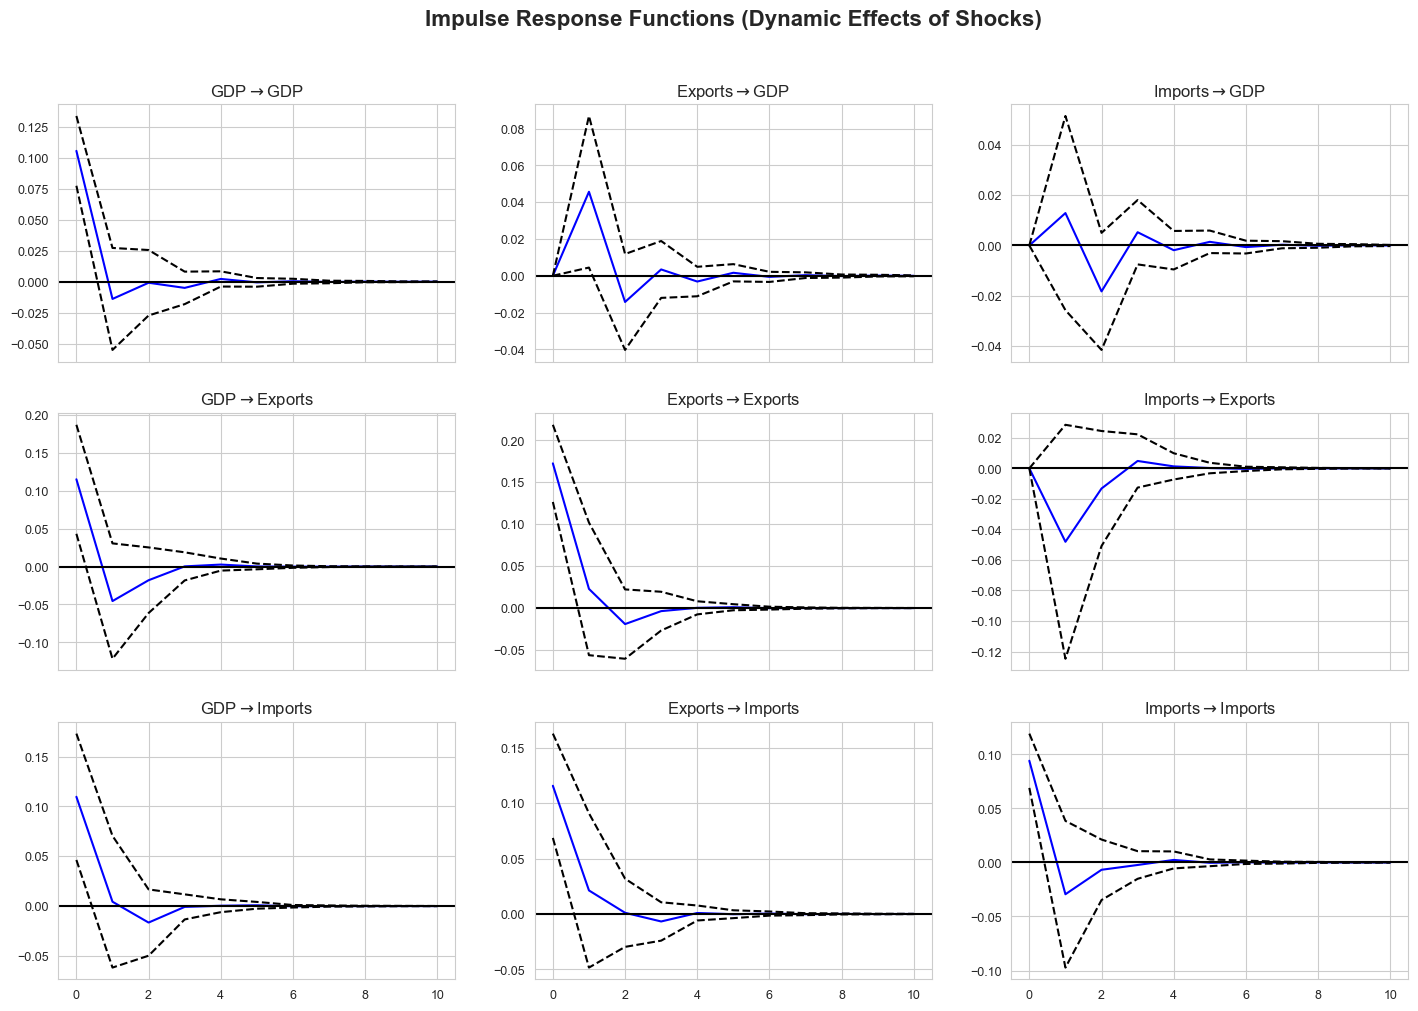

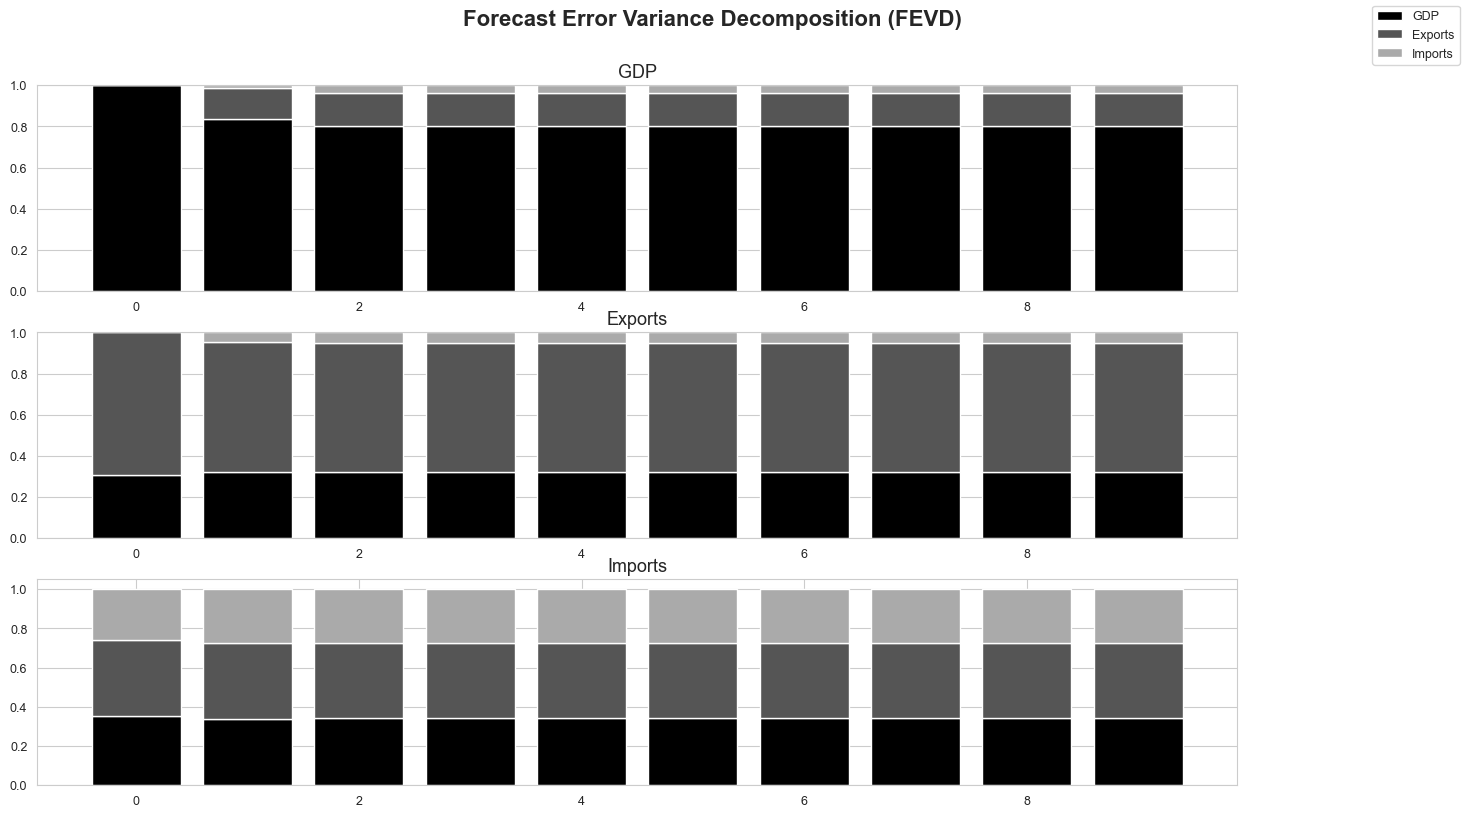


12.3 Out-of-Sample Forecasting Power Evaluation (Train: 1995-2018, Test: 2019-2023)

Out-of-Sample RMSE (Lower is better):
  • OLS Forecast RMSE: 0.04428
  • VAR Forecast RMSE: 0.05978


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


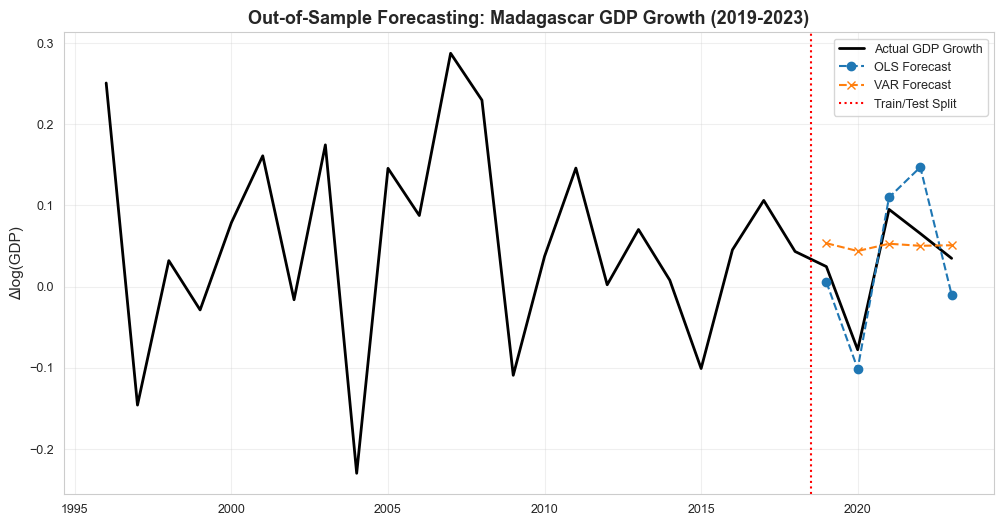


Interpretation: The model with the lowest RMSE demonstrates superior out-of-sample predictive power.

✓ Advanced Analysis Complete.


In [48]:
print("\n" + "=" * 80)
print("PART 12: ADVANCED FORECASTING AND SHOCK ANALYSIS")
print("-" * 80)

# 12.1 Structural Break Dummies
print("\n12.1 Structural Break Analysis")
df_dlog_sb = df_dlog.copy()
df_dlog_sb['Crisis_2009'] = 0
if 2009 in df_dlog_sb.index:
    df_dlog_sb.loc[2009, 'Crisis_2009'] = 1

df_dlog_sb['COVID_2020'] = 0
if 2020 in df_dlog_sb.index:
    df_dlog_sb.loc[2020, 'COVID_2020'] = 1

X_train_sb = sm.add_constant(df_dlog_sb[['Exports', 'Imports', 'Crisis_2009', 'COVID_2020']])
ols_model_sb = sm.OLS(df_dlog_sb['GDP'], X_train_sb).fit()

print("\nOLS with Structural Break Dummies (2009 Crisis & 2020 COVID):")
print("-" * 80)
print(ols_model_sb.summary())

# 12.2 Impulse Response Functions (IRF) and FEVD
print("\n12.2 VAR Impulse Response Functions (IRF) and FEVD")
var_data = df_dlog.dropna()
var_model = VAR(var_data)
# Force lag 1 or 2 for meaningful IRF
p_opt = var_model.select_order(maxlags=2).aic
if p_opt == 0:
    p_opt = 1 # Force at least 1 lag for dynamics
var_res = var_model.fit(p_opt)

# IRF
irf = var_res.irf(10)
fig = irf.plot(orth=True, figsize=(15, 10))
plt.suptitle('Impulse Response Functions (Dynamic Effects of Shocks)', y=1.02, fontsize=16, fontweight='bold')
plt.savefig('fig_12_irf.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# FEVD
fevd = var_res.fevd(10)
fig = fevd.plot(figsize=(15, 8))
plt.suptitle('Forecast Error Variance Decomposition (FEVD)', y=1.02, fontsize=16, fontweight='bold')
plt.savefig('fig_12_fevd.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# 12.3 Out-of-Sample Forecasting
print("\n12.3 Out-of-Sample Forecasting Power Evaluation (Train: 1995-2018, Test: 2019-2023)")
train_dlog = df_dlog.loc[:2018]
test_dlog = df_dlog.loc[2019:]

if len(test_dlog) > 0:
    # OLS Forecast
    X_train = sm.add_constant(train_dlog[['Exports', 'Imports']])
    ols_model_train = sm.OLS(train_dlog['GDP'], X_train).fit()
    X_test = sm.add_constant(test_dlog[['Exports', 'Imports']])
    ols_pred = ols_model_train.predict(X_test)
    ols_rmse = np.sqrt(((ols_pred - test_dlog['GDP'])**2).mean())

    # VAR Forecast
    var_train = VAR(train_dlog).fit(p_opt)
    var_pred_vals = var_train.forecast(train_dlog.values[-var_train.k_ar:], steps=len(test_dlog))
    var_pred = pd.Series(var_pred_vals[:, 0], index=test_dlog.index) # GDP is index 0
    var_rmse = np.sqrt(((var_pred - test_dlog['GDP'])**2).mean())

    print(f"\nOut-of-Sample RMSE (Lower is better):")
    print(f"  • OLS Forecast RMSE: {ols_rmse:.5f}")
    print(f"  • VAR Forecast RMSE: {var_rmse:.5f}")
    
    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(df_dlog.index, df_dlog['GDP'], label='Actual GDP Growth', color='black', linewidth=2)
    plt.plot(test_dlog.index, ols_pred, label='OLS Forecast', linestyle='--', marker='o')
    plt.plot(test_dlog.index, var_pred, label='VAR Forecast', linestyle='--', marker='x')
    plt.axvline(2018.5, color='red', linestyle=':', label='Train/Test Split')
    plt.title('Out-of-Sample Forecasting: Madagascar GDP Growth (2019-2023)', fontweight='bold')
    plt.ylabel('Δlog(GDP)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('fig_12_out_of_sample_forecast.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    print("\nInterpretation: The model with the lowest RMSE demonstrates superior out-of-sample predictive power.")

print("\n✓ Advanced Analysis Complete.")